# MSE 232 Project - Group 13
## Optimizing the 2026 FIFA World Cup Group-Stage Schedule

# 1. Data Import and Preparation

### This section imports the datasets and creates the sets and parameters used in the optimization models. The project data is stored in separate CSV files so that the optimization model can be updated without changing the model formulation.

In [309]:
# libraries
import pandas as pd
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# csv files
teams = pd.read_csv("teams.csv")
venues = pd.read_csv("venues.csv")
matches = pd.read_csv("matches.csv")
travel = pd.read_csv("travel.csv")
weather = pd.read_csv("weather.csv")
audience_regions = pd.read_csv("audience_regions.csv")

In [310]:
# data inspection

print("Teams:", teams.shape)
print("Venues:", venues.shape)
print("Matches:", matches.shape)
print("Travel:", travel.shape)
print("Weather:", weather.shape)
print("Audience Regions:", audience_regions.shape)

display(teams.head())
display(venues.head())
display(matches.head())
display(travel.head())

print("Number of teams:", teams["team_id"].nunique())
print("Number of venues:", venues["venue_id"].nunique())
print("Number of matches:", matches["match_id"].nunique())
print("Number of travel combinations:", len(travel))

Teams: (48, 16)
Venues: (16, 16)
Matches: (72, 8)
Travel: (768, 16)
Weather: (3536, 7)
Audience Regions: (46, 5)


,team_id,team_name,group,home_country,home_utc_offset,base_camp_name,base_camp_city,base_camp_country,base_camp_utc_offset,base_camp_airport_code,base_camp_airport_longitude,base_camp_airport_latitude,base_camp_longitude,base_camp_latitude,driving_distance_airport_to_basecamp_one_way_km,driving_time_airport_to_basecamp_one_way_hours
0,1,Czech Republic,A,Czech Republic,2.0,Mansfield Multipurpose Stadium,Dallas,United States,-5,DFW,-97.0403,32.8998,-97.0740,32.5630,42.040,0.634
1,2,Mexico,A,Mexico,-6.0,Centro de Alto Rendimiento (CAR),Mexico City,Mexico,-6,MEX,-99.0721,19.4363,-99.1437,19.3558,18.502,0.342
2,3,South Africa,A,South Africa,2.0,CF Pachuca - Universidad Del Futbol,Pachuca,Mexico,-6,NLU,-99.0159,19.7581,-98.7424,20.0600,53.988,0.916
3,4,South Korea,A,South Korea,9.0,Chivas Verde Valle,Guadalajara,Mexico,-6,GDL,-103.3112,20.5218,-103.4300,20.6650,29.045,0.534
4,5,Bosnia & Herzegovina,B,Bosnia & Herzegovina,2.0,RSL Stadium,Sandy,United States,-6,SLC,-111.9791,40.7899,-111.8933,40.5829,32.092,0.484


,venue_id,venue_name,city,country,utc_offset,iana_timezone,capacity,roof_type,weather_protected,venue_longitude,venue_latitude,venue_airport_code,venue_airport_longitude,venue_airport_latitude,driving_distance_airport_to_venue_one_way_km,driving_time_airport_to_venue_one_way_hours
0,1,Toronto Stadium,Toronto,Canada,-4,America/Toronto,45736,Open,0,-79.4186,43.6332,YYZ,-79.6248,43.6777,27.260,0.486
1,2,BC Place Vancouver,Vancouver,Canada,-7,America/Vancouver,54500,Retractable,1,-123.1120,49.2768,YVR,-123.1792,49.1947,13.873,0.378
2,3,Mexico City Stadium,Mexico City,Mexico,-6,America/Mexico_City,83000,Open,0,-99.1504,19.3029,MEX,-99.0721,19.4363,21.166,0.395
3,4,Guadalajara Stadium,Guadalajara,Mexico,-6,America/Mexico_City,48071,Open,0,-103.4626,20.6818,GDL,-103.3112,20.5218,30.333,0.621
4,5,Monterrey Stadium,Monterrey,Mexico,-6,America/Monterrey,53500,Open,0,-100.2444,25.6692,MTY,-100.1070,25.7785,23.088,0.421


,match_id,group,group_round,team_1_id,team_2_id,match_date,actual_venue_id,actual_kickoff_utc
0,1,A,1,2,3,2026-06-11,3,19:00
1,2,A,1,4,1,2026-06-11,4,2:00
2,3,B,2,6,5,2026-06-12,1,19:00
3,4,D,2,16,14,2026-06-12,11,1:00
4,5,B,3,7,8,2026-06-13,15,19:00


,team_id,venue_id,travel_mode,transportation_method,origin_longitude,origin_latitude,destination_longitude,destination_latitude,driving_distance_airport_to_basecamp_one_way_km,driving_time_airport_to_basecamp_one_way_hours,driving_distance_airport_to_venue_one_way_km,driving_time_airport_to_venue_one_way_hours,airport_to_airport_distance_kilometres,airport_to_airport_time_hours,total_distance_travelled_kilometres,total_time_travelled_hours
0,1,1,FLIGHT,car + plane,-97.0403,32.8998,-79.6248,43.6777,42.04,0.634,27.260,0.486,1928.763,2.838,1998.063,3.958
1,1,2,FLIGHT,car + plane,-97.0403,32.8998,-123.1792,49.1947,42.04,0.634,13.873,0.378,2818.702,3.917,2874.615,4.929
2,1,3,FLIGHT,car + plane,-97.0403,32.8998,-99.0721,19.4363,42.04,0.634,21.166,0.395,1510.636,2.331,1573.842,3.360
3,1,4,FLIGHT,car + plane,-97.0403,32.8998,-103.3112,20.5218,42.04,0.634,30.333,0.621,1509.849,2.330,1582.222,3.585
4,1,5,FLIGHT,car + plane,-97.0403,32.8998,-100.1070,25.7785,42.04,0.634,23.088,0.421,845.678,1.525,910.806,2.580


Number of teams: 48
Number of venues: 16
Number of matches: 72
Number of travel combinations: 768


In [311]:
# data formatting

matches["match_date"] = pd.to_datetime(matches["match_date"])
weather["date"] = pd.to_datetime(weather["date"])

teams["team_id"] = teams["team_id"].astype(int)
venues["venue_id"] = venues["venue_id"].astype(int)

matches["match_id"] = matches["match_id"].astype(int)
matches["team_1_id"] = matches["team_1_id"].astype(int)
matches["team_2_id"] = matches["team_2_id"].astype(int)
matches["actual_venue_id"] = matches["actual_venue_id"].astype(int)

travel["team_id"] = travel["team_id"].astype(int)
travel["venue_id"] = travel["venue_id"].astype(int)

In [312]:
# defining sets

Teams = teams["team_id"].tolist()
Venues = venues["venue_id"].tolist()
Matches = matches["match_id"].tolist()

Groups = sorted(matches["group"].unique().tolist())
Dates = sorted(matches["match_date"].unique().tolist())

Times = list(range(10, 23))

In [313]:
# derive actual group-stage round from each team's match sequence

round_assignment = {}

for i in Teams:

    matches_i = matches[
        (matches["team_1_id"] == i)
        | (matches["team_2_id"] == i)
    ].copy()

    matches_i = matches_i.sort_values(
        ["match_date", "match_id"]
    )

    for r, m in enumerate(
        matches_i["match_id"].tolist(),
        start=1
    ):

        if m in round_assignment:

            if round_assignment[m] != r:
                raise ValueError(
                    "Inconsistent round assignment for match "
                    + str(m)
                )

        else:
            round_assignment[m] = r


matches["group_round"] = (
    matches["match_id"]
    .map(round_assignment)
    .astype(int)
)

In [314]:
# match parameters

match_group = dict(zip(
    matches["match_id"],
    matches["group"]
))

group_round = dict(zip(
    matches["match_id"],
    matches["group_round"]
))

team_1 = dict(zip(
    matches["match_id"],
    matches["team_1_id"]
))

team_2 = dict(zip(
    matches["match_id"],
    matches["team_2_id"]
))

match_date = dict(zip(
    matches["match_id"],
    matches["match_date"]
))

actual_venue = dict(zip(
    matches["match_id"],
    matches["actual_venue_id"]
))

actual_kickoff_utc = dict(zip(
    matches["match_id"],
    matches["actual_kickoff_utc"]
))

In [315]:
# team parameters

team_name = dict(zip(
    teams["team_id"],
    teams["team_name"]
))

base_camp_utc_offset = dict(zip(
    teams["team_id"],
    teams["base_camp_utc_offset"]
))

In [316]:
# venue parameters

venue_name = dict(zip(
    venues["venue_id"],
    venues["venue_name"]
))

venue_city = dict(zip(
    venues["venue_id"],
    venues["city"]
))

venue_country = dict(zip(
    venues["venue_id"],
    venues["country"]
))

venue_utc_offset = dict(zip(
    venues["venue_id"],
    venues["utc_offset"]
))

venue_capacity = dict(zip(
    venues["venue_id"],
    venues["capacity"]
))

In [317]:
# travel parameters

# duplicate travel check
duplicate_travel = travel.duplicated(
    subset=["team_id", "venue_id"]
).sum()

print("Duplicate travel combinations:", duplicate_travel)

travel_time = {}

for _, row in travel.iterrows():
    i = row["team_id"]
    v = row["venue_id"]

    travel_time[(i, v)] = row["total_time_travelled_hours"]

travel_distance = {}

for _, row in travel.iterrows():
    i = row["team_id"]
    v = row["venue_id"]

    travel_distance[(i, v)] = row["total_distance_travelled_kilometres"]

# missing travel check

missing_travel = []

for i in Teams:
    for v in Venues:
        if (i, v) not in travel_time:
            missing_travel.append((i, v))

print("Missing travel combinations:", len(missing_travel))

Duplicate travel combinations: 0
Missing travel combinations: 0


In [318]:
# helper sets

# matches by date

matches_by_date = {}

for d in Dates:
    matches_by_date[d] = []

    for m in Matches:
        if match_date[m] == d:
            matches_by_date[d].append(m)

# matches for each team
team_matches = {}

for i in Teams:
    team_matches[i] = []

    for m in Matches:
        if team_1[m] == i or team_2[m] == i:
            team_matches[i].append(m)

for i in Teams:
    team_matches[i] = sorted(
        team_matches[i],
        key=lambda m: match_date[m]
    )

# matches by round
Round1Matches = []
Round2Matches = []
Round3Matches = []

for m in Matches:

    if group_round[m] == 1:
        Round1Matches.append(m)

    elif group_round[m] == 2:
        Round2Matches.append(m)

    elif group_round[m] == 3:
        Round3Matches.append(m)

# matches by group and round
matches_by_group_round = {}

for g in Groups:
    for r in [1, 2, 3]:

        matches_by_group_round[(g, r)] = []

        for m in Matches:
            if match_group[m] == g and group_round[m] == r:
                matches_by_group_round[(g, r)].append(m)

# 2. Metric Preparation and Evaluation Parameters

### This section defines the additional parameters, functions, and lookup tables used to evaluate both the FIFA schedule and the optimized schedules. Defining these measures before evaluating any schedule ensures that FIFA and all optimization models are assessed using the same methodology.

In [319]:
# additional venue parameters

weather_protected = dict(zip(
    venues["venue_id"],
    venues["weather_protected"]
))

roof_type = dict(zip(
    venues["venue_id"],
    venues["roof_type"]
))

In [320]:
# heat index function

def calculate_heat_index(temp_f, humidity):

    simple_hi = 0.5 * (
        temp_f
        + 61
        + 1.2 * (temp_f - 68)
        + 0.094 * humidity
    )

    simple_hi = (simple_hi + temp_f) / 2

    if simple_hi < 80:
        return simple_hi

    hi = (
        -42.379
        + 2.04901523 * temp_f
        + 10.14333127 * humidity
        - 0.22475541 * temp_f * humidity
        - 0.00683783 * temp_f**2
        - 0.05481717 * humidity**2
        + 0.00122874 * temp_f**2 * humidity
        + 0.00085282 * temp_f * humidity**2
        - 0.00000199 * temp_f**2 * humidity**2
    )

    return hi

In [321]:
# heat index for weather data

weather["heat_index_f"] = weather.apply(
    lambda row: calculate_heat_index(
        row["temperature_f"],
        row["humidity_pct"]
    ),
    axis=1
)

In [322]:
# weather lookup

weather_lookup = {}

for _, row in weather.iterrows():

    key = (
        row["venue_id"],
        row["date"],
        row["hour_local"]
    )

    weather_lookup[key] = row["heat_index_f"]

duplicate_weather = weather.duplicated(
    subset=["venue_id", "date", "hour_local"]
).sum()

print("Duplicate weather combinations:", duplicate_weather)

Duplicate weather combinations: 0


In [323]:
# time zone difference lookup

timezone_difference = {}

for i in Teams:
    for v in Venues:

        timezone_difference[(i, v)] = abs(
            base_camp_utc_offset[i]
            - venue_utc_offset[v]
        )

# 3. FIFA Schedule Baseline Analysis
### This section evaluates FIFA's actual group-stage schedule using the common metrics defined above. Because the FIFA venue and kickoff assignments are fixed, no optimization is performed in this section. The existing FIFA schedule is evaluated directly and used as the benchmark for comparison with the optimized schedules.

In [324]:
# constructing fifa schedule

fifa_schedule = matches[
    [
        "match_id",
        "group",
        "group_round",
        "team_1_id",
        "team_2_id",
        "match_date",
        "actual_venue_id",
        "actual_kickoff_utc"
    ]
].copy()

fifa_schedule["team_1_name"] = fifa_schedule["team_1_id"].map(team_name)
fifa_schedule["team_2_name"] = fifa_schedule["team_2_id"].map(team_name)

fifa_schedule["venue_name"] = fifa_schedule["actual_venue_id"].map(venue_name)
fifa_schedule["venue_city"] = fifa_schedule["actual_venue_id"].map(venue_city)
fifa_schedule["venue_country"] = fifa_schedule["actual_venue_id"].map(venue_country)

In [325]:
# adding world cup 2026 actual kickoff times

def create_utc_kickoff_datetime(local_date, utc_time, utc_offset):

    # make sure kickoff time is a Python time object
    if isinstance(utc_time, str):
        utc_time = pd.to_datetime(
            utc_time,
            format="%H:%M"
        ).time()

    utc_minutes = utc_time.hour * 60 + utc_time.minute

    local_minutes = (
        utc_minutes + int(utc_offset * 60)
    ) % (24 * 60)

    local_hour = local_minutes // 60
    local_minute = local_minutes % 60

    local_datetime = (
        pd.Timestamp(local_date)
        + pd.Timedelta(hours=local_hour)
        + pd.Timedelta(minutes=local_minute)
    )

    utc_datetime = (
        local_datetime
        - pd.Timedelta(hours=utc_offset)
    )

    return utc_datetime


fifa_schedule["kickoff_datetime_utc"] = fifa_schedule.apply(
    lambda row: create_utc_kickoff_datetime(
        row["match_date"],
        row["actual_kickoff_utc"],
        venue_utc_offset[row["actual_venue_id"]]
    ),
    axis=1
)

In [326]:
# fifa schedule travel analysis

fifa_total_travel_time = 0

for m in Matches:

    i = team_1[m]
    j = team_2[m]
    v = actual_venue[m]

    fifa_total_travel_time += 2 * travel_time[(i, v)]
    fifa_total_travel_time += 2 * travel_time[(j, v)]

print(
    "FIFA total team travel time:",
    round(fifa_total_travel_time, 2),
    "hours"
)

FIFA total team travel time: 641.49 hours


In [327]:
# fifa travel by team
fifa_team_travel = {}

for i in Teams:

    fifa_team_travel[i] = 0

    for m in team_matches[i]:

        v = actual_venue[m]

        fifa_team_travel[i] += (
            2 * travel_time[(i, v)]
        )

fifa_team_travel_df = pd.DataFrame({
    "team_id": Teams,
    "team_name": [team_name[i] for i in Teams],
    "total_travel_time_hours": [
        fifa_team_travel[i]
        for i in Teams
    ]
})

In [328]:
# summary metrics for fifa schedule

fifa_avg_team_travel = (
    fifa_team_travel_df["total_travel_time_hours"].mean()
)

fifa_max_team_travel = (
    fifa_team_travel_df["total_travel_time_hours"].max()
)

fifa_min_team_travel = (
    fifa_team_travel_df["total_travel_time_hours"].min()
)

fifa_std_team_travel = (
    fifa_team_travel_df["total_travel_time_hours"].std(ddof=0)
)

In [329]:
# fifa rest and effective recovery

fifa_recovery_rows = []

for i in Teams:

    matches_i = team_matches[i]

    for k in range(len(matches_i) - 1):

        previous_match = matches_i[k]
        next_match = matches_i[k + 1]

        previous_row = fifa_schedule[
            fifa_schedule["match_id"] == previous_match
        ].iloc[0]

        next_row = fifa_schedule[
            fifa_schedule["match_id"] == next_match
        ].iloc[0]

        previous_kickoff = previous_row["kickoff_datetime_utc"]
        next_kickoff = next_row["kickoff_datetime_utc"]

        raw_rest_hours = (
            next_kickoff - previous_kickoff
        ).total_seconds() / 3600

        previous_venue = previous_row["actual_venue_id"]
        next_venue = next_row["actual_venue_id"]

        recovery_travel_time = (
            travel_time[(i, previous_venue)]
            + travel_time[(i, next_venue)]
        )

        effective_recovery_hours = (
            raw_rest_hours
            - recovery_travel_time
        )

        fifa_recovery_rows.append({
            "team_id": i,
            "team_name": team_name[i],
            "previous_match": previous_match,
            "next_match": next_match,
            "raw_rest_hours": raw_rest_hours,
            "recovery_travel_time_hours": recovery_travel_time,
            "effective_recovery_hours": effective_recovery_hours
        })

fifa_recovery = pd.DataFrame(fifa_recovery_rows)

In [330]:
# summary metrics for fifa recovery

fifa_min_raw_rest = fifa_recovery["raw_rest_hours"].min()
fifa_avg_raw_rest = fifa_recovery["raw_rest_hours"].mean()

fifa_min_effective_recovery = (
    fifa_recovery["effective_recovery_hours"].min()
)

fifa_avg_effective_recovery = (
    fifa_recovery["effective_recovery_hours"].mean()
)

fifa_std_effective_recovery = (
    fifa_recovery[
        "effective_recovery_hours"
    ].std(ddof=0)
)

fifa_recovery["meets_72_hour_raw_rest"] = (
    fifa_recovery["raw_rest_hours"] >= 72
)

print("Minimum FIFA raw rest:", round(fifa_min_raw_rest, 2))
print("Average FIFA raw rest:", round(fifa_avg_raw_rest, 2))

print(
    "Minimum FIFA effective recovery:",
    round(fifa_min_effective_recovery, 2)
)

print(
    "Average FIFA effective recovery:",
    round(fifa_avg_effective_recovery, 2)
)

print(
    "Intervals below 72 hours raw rest:",
    (~fifa_recovery["meets_72_hour_raw_rest"]).sum()
)

print("Recovery intervals evaluated:", len(fifa_recovery))

if len(fifa_recovery) != 96:
    raise ValueError("Expected 96 FIFA recovery intervals.")

Minimum FIFA raw rest: 91.0
Average FIFA raw rest: 133.42
Minimum FIFA effective recovery: 86.0
Average FIFA effective recovery: 128.94
Intervals below 72 hours raw rest: 0
Recovery intervals evaluated: 96


In [331]:
# fifa schedule time zone analysis

fifa_timezone_rows = []

for m in Matches:

    v = actual_venue[m]

    for i in [team_1[m], team_2[m]]:

        fifa_timezone_rows.append({
            "match_id": m,
            "team_id": i,
            "team_name": team_name[i],
            "venue_id": v,
            "timezone_difference_hours":
                timezone_difference[(i, v)]
        })

fifa_timezone = pd.DataFrame(fifa_timezone_rows)

fifa_avg_timezone_difference = (
    fifa_timezone["timezone_difference_hours"].mean()
)

fifa_max_timezone_difference = (
    fifa_timezone["timezone_difference_hours"].max()
)

In [332]:
# fifa schedule weather analysis

def utc_time_to_local_hour(utc_time, utc_offset):

    # convert string to Python time object if needed
    if isinstance(utc_time, str):
        utc_time = pd.to_datetime(
            utc_time,
            format="%H:%M"
        ).time()

    utc_minutes = utc_time.hour * 60 + utc_time.minute

    local_minutes = (
        utc_minutes + int(utc_offset * 60)
    ) % (24 * 60)

    local_hour = local_minutes // 60

    return int(local_hour)


# calculate local kickoff hour for each FIFA match
fifa_schedule["kickoff_local_hour"] = fifa_schedule.apply(
    lambda row: utc_time_to_local_hour(
        row["actual_kickoff_utc"],
        venue_utc_offset[row["actual_venue_id"]]
    ),
    axis=1
)


# check that all required weather observations exist
missing_fifa_weather = []

for _, row in fifa_schedule.iterrows():

    v = row["actual_venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    if (v, d, h) not in weather_lookup:
        missing_fifa_weather.append((v, d, h))

print("Missing FIFA weather lookups:", len(missing_fifa_weather))

if len(missing_fifa_weather) > 0:
    raise ValueError("Missing weather data for FIFA schedule.")


# calculate FIFA weather exposure
fifa_weather_rows = []

for _, row in fifa_schedule.iterrows():

    m = row["match_id"]
    v = row["actual_venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    heat_index = weather_lookup[(v, d, h)]

    if weather_protected[v] == 1:
        weather_exposure = 0
    else:
        weather_exposure = heat_index

    fifa_weather_rows.append({
        "match_id": m,
        "venue_id": v,
        "venue_name": venue_name[v],
        "date": d,
        "local_hour": h,
        "heat_index_f": heat_index,
        "weather_protected": weather_protected[v],
        "weather_exposure": weather_exposure
    })


fifa_weather = pd.DataFrame(fifa_weather_rows)

fifa_total_weather_exposure = (
    fifa_weather["weather_exposure"].sum()
)

fifa_avg_weather_exposure = (
    fifa_weather["weather_exposure"].mean()
)

fifa_max_weather_exposure = (
    fifa_weather["weather_exposure"].max()
)

Missing FIFA weather lookups: 0


In [333]:
# fifa schedule seating opportunity

fifa_seating_opportunity = 0

for m in Matches:
    v = actual_venue[m]
    fifa_seating_opportunity += venue_capacity[v]

In [334]:
# fifa schedule venue and country usage

fifa_venue_usage = {}

for v in Venues:
    fifa_venue_usage[v] = 0

for m in Matches:
    v = actual_venue[m]
    fifa_venue_usage[v] += 1

fifa_venue_use_std = np.std(
    [
        fifa_venue_usage[v]
        for v in Venues
    ],
    ddof=0
)

fifa_country_usage = {}

for m in Matches:

    v = actual_venue[m]
    country = venue_country[v]

    if country not in fifa_country_usage:
        fifa_country_usage[country] = 0

    fifa_country_usage[country] += 1

In [335]:
# fifa schedule baseline summary

fifa_baseline = {

    "total_travel_time_hours":
        fifa_total_travel_time,

    "travel_time_std_hours":
        fifa_std_team_travel,

    "minimum_effective_recovery_hours":
        fifa_min_effective_recovery,

    "effective_recovery_std_hours":
        fifa_std_effective_recovery,

    "average_timezone_difference_hours":
        fifa_avg_timezone_difference,

    "total_weather_exposure":
        fifa_total_weather_exposure,

    "seating_opportunity":
        fifa_seating_opportunity,

    "venue_use_std":
        fifa_venue_use_std
}


fifa_baseline_df = pd.DataFrame(
    fifa_baseline.items(),
    columns=[
        "metric",
        "value"
    ]
)


display(
    fifa_baseline_df.round(2)
)

,metric,value
0,total_travel_time_hours,641.49
1,travel_time_std_hours,4.22
2,minimum_effective_recovery_hours,86.00
3,effective_recovery_std_hours,19.46
4,average_timezone_difference_hours,0.33
5,total_weather_exposure,3926.58
6,seating_opportunity,4793722.00
7,venue_use_std,0.71


# 4. Model 1 (Only Minimizing Travel Time)
### Model 1 minimizes total team travel time while keeping all group-stage matchups and match dates fixed. For each possible match–venue assignment, the travel-time coefficient includes round-trip travel for both participating teams because each team is assumed to return to its official base camp after every match. Candidate kickoff times are whole-hour local venue times from 10:00 to 22:00.

In [336]:
# shared parameters (used in later models as well)

candidate_utc_datetime = {}

for m in Matches:
    for v in Venues:
        for t in Times:

            local_datetime = (
                pd.Timestamp(match_date[m])
                + pd.Timedelta(hours=t)
            )

            candidate_utc_datetime[(m, v, t)] = (
                local_datetime
                - pd.Timedelta(hours=venue_utc_offset[v])
            )

# numeric UTC kickoff time measured in hours from tournament start

tournament_start = min(Dates)

candidate_utc_hour = {}

for m in Matches:
    for v in Venues:
        for t in Times:

            candidate_utc_hour[(m, v, t)] = (
                candidate_utc_datetime[(m, v, t)]
                - tournament_start
            ).total_seconds() / 3600

In [337]:
# model 1 specific parameters

model1_travel_time = {}

for m in Matches:
    for v in Venues:

        i = team_1[m]
        j = team_2[m]

        model1_travel_time[(m, v)] = (
            2 * travel_time[(i, v)]
            + 2 * travel_time[(j, v)]
        )

In [338]:
# creating the model

model1 = gp.Model("Model_1_Travel_Time")

# decision variables

x = model1.addVars(
    Matches,
    Venues,
    Times,
    vtype=GRB.BINARY,
    name="x"
)

# selected UTC kickoff time for each match

kickoff_utc = model1.addVars(
    Matches,
    vtype=GRB.CONTINUOUS,
    name="kickoff_utc"
)

# objective function

model1.setObjective(
    gp.quicksum(
        model1_travel_time[(m, v)] * x[m, v, t]
        for m in Matches
        for v in Venues
        for t in Times
    ),
    GRB.MINIMIZE
)

# every match is assigned exactly once

for m in Matches:

    model1.addConstr(
        gp.quicksum(
            x[m, v, t]
            for v in Venues
            for t in Times
        ) == 1,
        name="MatchAssignment_" + str(m)
    )


# link each match to its selected UTC kickoff time

for m in Matches:

    model1.addConstr(
        kickoff_utc[m]
        ==
        gp.quicksum(
            candidate_utc_hour[(m, v, t)]
            * x[m, v, t]
            for v in Venues
            for t in Times
        ),
        name="KickoffTime_" + str(m)
    )


# at most one match per venue per local date

for v in Venues:
    for d in Dates:

        model1.addConstr(
            gp.quicksum(
                x[m, v, t]
                for m in matches_by_date[d]
                for t in Times
            ) <= 1,
            name="VenueDailyCapacity_"
            + str(v) + "_"
            + str(d)
        )

# minimum stadium usage

minimum_venue_matches = 3

for v in Venues:

    model1.addConstr(
        gp.quicksum(
            x[m, v, t]
            for m in Matches
            for t in Times
        ) >= minimum_venue_matches,
        name="MinimumVenueUsage_" + str(v)
    )

# round 1 and round 2 kickoff spacing

EarlyRoundMatches = (
    Round1Matches + Round2Matches
)

minimum_kickoff_gap = 3
big_M = 500

early_match_pairs = []

for index1 in range(len(EarlyRoundMatches)):
    for index2 in range(
        index1 + 1,
        len(EarlyRoundMatches)
    ):

        m1 = EarlyRoundMatches[index1]
        m2 = EarlyRoundMatches[index2]

        date_difference = abs(
            (
                match_date[m2]
                - match_date[m1]
            ).days
        )

        if date_difference <= 1:
            early_match_pairs.append(
                (m1, m2)
            )


early_order = model1.addVars(
    early_match_pairs,
    vtype=GRB.BINARY,
    name="early_order"
)


for m1, m2 in early_match_pairs:

    model1.addConstr(
        kickoff_utc[m2]
        - kickoff_utc[m1]
        >=
        minimum_kickoff_gap
        - big_M
        * (1 - early_order[m1, m2]),
        name="EarlySpacing1_"
        + str(m1) + "_"
        + str(m2)
    )

    model1.addConstr(
        kickoff_utc[m1]
        - kickoff_utc[m2]
        >=
        minimum_kickoff_gap
        - big_M
        * early_order[m1, m2],
        name="EarlySpacing2_"
        + str(m1) + "_"
        + str(m2)
    )


# check round 3 match pairs

for g in Groups:

    round3_matches = (
        matches_by_group_round[(g, 3)]
    )

    if len(round3_matches) != 2:
        raise ValueError(
            "Expected exactly 2 Round 3 matches for Group "
            + str(g)
        )


# round 3 simultaneous kickoff constraints

for g in Groups:

    round3_matches = (
        matches_by_group_round[(g, 3)]
    )

    m1 = round3_matches[0]
    m2 = round3_matches[1]

    model1.addConstr(
        kickoff_utc[m1]
        ==
        kickoff_utc[m2],
        name="Round3Simultaneous_"
        + str(g)
    )


# minimum 72-hour raw rest

minimum_raw_rest = 72

for i in Teams:

    matches_i = team_matches[i]

    for k in range(
        len(matches_i) - 1
    ):

        m1 = matches_i[k]
        m2 = matches_i[k + 1]

        model1.addConstr(
            kickoff_utc[m2]
            - kickoff_utc[m1]
            >= minimum_raw_rest,
            name="MinimumRest_"
            + str(i) + "_"
            + str(m1) + "_"
            + str(m2)
        )

# validate group-round structure

print()
print("Round 1 matches:", len(Round1Matches))
print("Round 2 matches:", len(Round2Matches))
print("Round 3 matches:", len(Round3Matches))
print()

# optimize model 1

model1.optimize()

# check model 1 solution status

if model1.Status == GRB.OPTIMAL:
    print("Model 1 optimal solution found.")
    print("Objective value:", model1.ObjVal)

elif model1.Status == GRB.INFEASIBLE:
    print("Model 1 is infeasible.")

else:
    print("Model 1 status:", model1.Status)


Round 1 matches: 24
Round 2 matches: 24
Round 3 matches: 24

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 1020 rows, 15288 columns and 61632 nonzeros (Min)
Model fingerprint: 0xae910ef4
Model has 14976 linear objective coefficients
Variable types: 72 continuous, 15216 integer (15216 binary)
Coefficient statistics:
  Matrix range     [1e+00, 5e+02]
  Objective range  [2e+00, 3e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+02]

Presolve removed 452 rows and 184 columns
Presolve time: 0.03s
Presolved: 568 rows, 15104 columns, 59952 nonzeros
Variable types: 0 continuous, 15104 integer (15044 binary)

Root relaxation: objective 4.958320e+02, 572 iterations, 0.01 seconds (0.03 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbe

In [339]:
# extracting model 1 optimized schedule

model1_schedule_rows = []

for m in Matches:

    for v in Venues:
        for t in Times:

            if x[m, v, t].X > 0.5:

                model1_schedule_rows.append({
                    "match_id": m,
                    "group": match_group[m],
                    "group_round": group_round[m],

                    "team_1_id": team_1[m],
                    "team_1_name":
                        team_name[team_1[m]],

                    "team_2_id": team_2[m],
                    "team_2_name":
                        team_name[team_2[m]],

                    "match_date":
                        match_date[m],

                    "venue_id": v,
                    "venue_name":
                        venue_name[v],

                    "venue_city":
                        venue_city[v],

                    "venue_country":
                        venue_country[v],

                    "kickoff_local_hour": t,

                    "kickoff_datetime_utc":
                        candidate_utc_datetime[
                            (m, v, t)
                        ]
                })


model1_schedule = pd.DataFrame(
    model1_schedule_rows
)

model1_schedule = (
    model1_schedule
    .sort_values(
        [
            "match_date",
            "kickoff_datetime_utc"
        ]
    )
    .reset_index(drop=True)
)

display(model1_schedule)

print(
    "Scheduled matches:",
    len(model1_schedule)
)

if len(model1_schedule) != 72:
    raise ValueError(
        "Expected 72 scheduled matches."
    )

# validate venue daily capacity

model1_venue_day_check = (
    model1_schedule
    .groupby(
        ["venue_id", "match_date"]
    )
    .size()
)

print(
    "Maximum matches at one venue "
    "on one date:",
    model1_venue_day_check.max()
)

# validate round 3 simultaneity

for g in Groups:

    round3_matches = (
        model1_schedule[
            (model1_schedule["group"] == g)
            &
            (
                model1_schedule[
                    "group_round"
                ] == 3
            )
        ]
    )

    kickoff_times = (
        round3_matches[
            "kickoff_datetime_utc"
        ].unique()
    )

    if len(kickoff_times) != 1:
        print(
            "Round 3 timing issue:",
            g
        )

,match_id,group,group_round,team_1_id,team_1_name,team_2_id,team_2_name,match_date,venue_id,venue_name,venue_city,venue_country,kickoff_local_hour,kickoff_datetime_utc
0,1,A,1,2,Mexico,3,South Africa,2026-06-11,3,Mexico City Stadium,Mexico City,Mexico,11,2026-06-11 17:00:00
1,2,A,1,4,South Korea,1,Czech Republic,2026-06-11,8,Dallas Stadium,Dallas,United States,22,2026-06-12 03:00:00
2,4,D,1,16,USA,14,Paraguay,2026-06-12,15,San Francisco Bay Area Stadium,San Francisco Bay Area,United States,12,2026-06-12 19:00:00
3,3,B,1,6,Canada,5,Bosnia & Herzegovina,2026-06-12,2,BC Place Vancouver,Vancouver,Canada,15,2026-06-12 22:00:00
4,6,C,1,9,Brazil,11,Morocco,2026-06-13,13,New York New Jersey Stadium,New York New Jersey,United States,10,2026-06-13 14:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,L,3,48,Panama,46,England,2026-06-27,1,Toronto Stadium,Toronto,Canada,10,2026-06-27 14:00:00
68,69,K,3,41,Colombia,43,Portugal,2026-06-27,4,Guadalajara Stadium,Guadalajara,Mexico,10,2026-06-27 16:00:00
69,70,K,3,42,DR Congo,44,Uzbekistan,2026-06-27,6,Atlanta Stadium,Atlanta,United States,12,2026-06-27 16:00:00
70,71,J,3,37,Algeria,39,Austria,2026-06-27,11,Los Angeles Stadium,Los Angeles,United States,10,2026-06-27 17:00:00


Scheduled matches: 72
Maximum matches at one venue on one date: 1


In [340]:
# model 1 performance metrics

# travel

model1_total_travel_time = 0

model1_team_travel = {
    i: 0
    for i in Teams
}

for _, row in model1_schedule.iterrows():

    i = row["team_1_id"]
    j = row["team_2_id"]
    v = row["venue_id"]

    team_1_travel = (
        2 * travel_time[(i, v)]
    )

    team_2_travel = (
        2 * travel_time[(j, v)]
    )

    model1_total_travel_time += (
        team_1_travel
        + team_2_travel
    )

    model1_team_travel[i] += (
        team_1_travel
    )

    model1_team_travel[j] += (
        team_2_travel
    )


model1_team_travel_df = pd.DataFrame({
    "team_id": Teams,

    "team_name": [
        team_name[i]
        for i in Teams
    ],

    "total_travel_time_hours": [
        model1_team_travel[i]
        for i in Teams
    ]
})


model1_avg_team_travel = (
    model1_team_travel_df[
        "total_travel_time_hours"
    ].mean()
)

model1_max_team_travel = (
    model1_team_travel_df[
        "total_travel_time_hours"
    ].max()
)

model1_min_team_travel = (
    model1_team_travel_df[
        "total_travel_time_hours"
    ].min()
)

model1_std_team_travel = (
    model1_team_travel_df[
        "total_travel_time_hours"
    ].std(ddof=0)
)

# rest and effective recovery

model1_recovery_rows = []

for i in Teams:

    team_schedule = model1_schedule[
        (model1_schedule["team_1_id"] == i)
        | (model1_schedule["team_2_id"] == i)
    ].copy()

    team_schedule = team_schedule.sort_values(
        "kickoff_datetime_utc"
    ).reset_index(drop=True)

    for k in range(len(team_schedule) - 1):

        previous_row = team_schedule.iloc[k]
        next_row = team_schedule.iloc[k + 1]

        raw_rest_hours = (
            next_row["kickoff_datetime_utc"]
            - previous_row["kickoff_datetime_utc"]
        ).total_seconds() / 3600

        previous_venue = (
            previous_row["venue_id"]
        )

        next_venue = (
            next_row["venue_id"]
        )

        recovery_travel_time = (
            travel_time[(i, previous_venue)]
            + travel_time[(i, next_venue)]
        )

        effective_recovery_hours = (
            raw_rest_hours
            - recovery_travel_time
        )

        model1_recovery_rows.append({
            "team_id": i,
            "team_name": team_name[i],
            "previous_match":
                previous_row["match_id"],
            "next_match":
                next_row["match_id"],
            "raw_rest_hours":
                raw_rest_hours,
            "recovery_travel_time_hours":
                recovery_travel_time,
            "effective_recovery_hours":
                effective_recovery_hours
        })


model1_recovery = pd.DataFrame(
    model1_recovery_rows
)

if len(model1_recovery) != 96:
    raise ValueError(
        "Expected 96 Model 1 recovery intervals."
    )

model1_min_raw_rest = (
    model1_recovery[
        "raw_rest_hours"
    ].min()
)

model1_avg_raw_rest = (
    model1_recovery[
        "raw_rest_hours"
    ].mean()
)

model1_min_effective_recovery = (
    model1_recovery[
        "effective_recovery_hours"
    ].min()
)

model1_avg_effective_recovery = (
    model1_recovery[
        "effective_recovery_hours"
    ].mean()
)

model1_std_effective_recovery = (
    model1_recovery[
        "effective_recovery_hours"
    ].std(ddof=0)
)

model1_intervals_below_72 = (
    model1_recovery[
        "raw_rest_hours"
    ] < 72
).sum()

# timezone difference

model1_timezone_rows = []

for _, row in model1_schedule.iterrows():

    m = row["match_id"]
    v = row["venue_id"]

    for i in [
        row["team_1_id"],
        row["team_2_id"]
    ]:

        model1_timezone_rows.append({
            "match_id": m,
            "team_id": i,
            "team_name": team_name[i],
            "venue_id": v,
            "timezone_difference_hours":
                timezone_difference[(i, v)]
        })


model1_timezone = pd.DataFrame(
    model1_timezone_rows
)

model1_avg_timezone_difference = (
    model1_timezone[
        "timezone_difference_hours"
    ].mean()
)

model1_max_timezone_difference = (
    model1_timezone[
        "timezone_difference_hours"
    ].max()
)

# weather exposure

missing_model1_weather = []

for _, row in model1_schedule.iterrows():

    v = row["venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    if (v, d, h) not in weather_lookup:
        missing_model1_weather.append(
            (v, d, h)
        )

if len(missing_model1_weather) > 0:
    raise ValueError(
        "Missing weather data for Model 1 schedule."
    )


model1_weather_rows = []

for _, row in model1_schedule.iterrows():

    m = row["match_id"]
    v = row["venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    heat_index = weather_lookup[
        (v, d, h)
    ]

    if weather_protected[v] == 1:
        weather_exposure = 0
    else:
        weather_exposure = heat_index

    model1_weather_rows.append({
        "match_id": m,
        "venue_id": v,
        "venue_name": venue_name[v],
        "date": d,
        "local_hour": h,
        "heat_index_f": heat_index,
        "weather_protected":
            weather_protected[v],
        "weather_exposure":
            weather_exposure
    })


model1_weather = pd.DataFrame(
    model1_weather_rows
)

model1_total_weather_exposure = (
    model1_weather[
        "weather_exposure"
    ].sum()
)

model1_avg_weather_exposure = (
    model1_weather[
        "weather_exposure"
    ].mean()
)

model1_max_weather_exposure = (
    model1_weather[
        "weather_exposure"
    ].max()
)

# seating opportunity

model1_seating_opportunity = 0

for _, row in model1_schedule.iterrows():

    v = row["venue_id"]

    model1_seating_opportunity += (
        venue_capacity[v]
    )

# venue and country usage

model1_venue_usage = {
    v: 0
    for v in Venues
}

for _, row in model1_schedule.iterrows():

    v = row["venue_id"]
    model1_venue_usage[v] += 1

model1_venue_use_std = np.std(
    [
        model1_venue_usage[v]
        for v in Venues
    ],
    ddof=0
)

model1_country_usage = {}

for _, row in model1_schedule.iterrows():

    v = row["venue_id"]
    country = venue_country[v]

    if country not in model1_country_usage:
        model1_country_usage[country] = 0

    model1_country_usage[country] += 1


model1_venue_usage_df = pd.DataFrame({
    "venue_id": Venues,

    "venue_name": [
        venue_name[v]
        for v in Venues
    ],

    "matches_hosted": [
        model1_venue_usage[v]
        for v in Venues
    ]
})


model1_country_usage_df = pd.DataFrame(
    model1_country_usage.items(),
    columns=[
        "country",
        "matches_hosted"
    ]
)

# model 1 summary dictionary

model1_summary = {

    "total_travel_time_hours":
        model1_total_travel_time,

    "travel_time_std_hours":
        model1_std_team_travel,

    "minimum_effective_recovery_hours":
        model1_min_effective_recovery,

    "effective_recovery_std_hours":
        model1_std_effective_recovery,

    "average_timezone_difference_hours":
        model1_avg_timezone_difference,

    "total_weather_exposure":
        model1_total_weather_exposure,

    "seating_opportunity":
        model1_seating_opportunity,

    "venue_use_std":
        model1_venue_use_std
}

# validation outputs

print(
    "Recovery intervals evaluated:",
    len(model1_recovery)
)

print(
    "Intervals below 72 hours raw rest:",
    model1_intervals_below_72
)

print(
    "Missing Model 1 weather lookups:",
    len(missing_model1_weather)
)

Recovery intervals evaluated: 96
Intervals below 72 hours raw rest: 0
Missing Model 1 weather lookups: 0


In [341]:
# fifa baseline vs model 1

comparison_rows = []

for metric in fifa_baseline:

    fifa_value = fifa_baseline[metric]
    model_value = model1_summary[metric]

    difference = (
        model_value - fifa_value
    )

    if fifa_value != 0:
        percent_change = (
            difference / fifa_value
        ) * 100
    else:
        percent_change = np.nan

    comparison_rows.append({
        "metric": metric,
        "FIFA Baseline": fifa_value,
        "Model 1": model_value,
        "difference": difference,
        "percent_change": percent_change
    })


model1_comparison = pd.DataFrame(
    comparison_rows
)

display(
    model1_comparison.round(2)
)

,metric,FIFA Baseline,Model 1,difference,percent_change
0,total_travel_time_hours,641.49,495.83,-145.66,-22.71
1,travel_time_std_hours,4.22,5.02,0.79,18.75
2,minimum_effective_recovery_hours,86.00,81.20,-4.80,-5.58
3,effective_recovery_std_hours,19.46,20.87,1.41,7.25
4,average_timezone_difference_hours,0.33,0.22,-0.11,-34.04
5,total_weather_exposure,3926.58,4274.11,347.53,8.85
6,seating_opportunity,4793722.00,4922049.00,128327.00,2.68
7,venue_use_std,0.71,1.97,1.26,178.39


# 5. Model 2 (Player Welfare Optimization)
### Model 2 focuses on player welfare through three objectives applied in priority order.

### 1. Maximize the minimum effective recovery time between consecutive matches.
### 2. Among schedules achieving the optimal minimum effective recovery, minimize total team time-zone displacement.
### 3. Among schedules preserving both of the previous optimal results, minimize total weather exposure.

### Effective recovery is defined as the raw time between consecutive match kickoffs minus the travel time from the previous match venue back to the team's base camp and from the base camp to the next match venue.

### The same fixed match dates, matchups, and tournament feasibility constraints used in Model 1 are retained.

In [342]:
# model 2 specific parameters

# recovery intervals: each team has two recovery intervals between its three matches

RecoveryIntervals2 = []

for i in Teams:

    matches_i = team_matches[i]
    for k in range(len(matches_i) - 1):
        RecoveryIntervals2.append(
            (i, k)
        )


# weather exposure for each possible assignment

model2_weather_exposure = {}

for m in Matches:
    for v in Venues:
        for t in Times:

            if weather_protected[v] == 1:
                model2_weather_exposure[(m, v, t)] = 0

            else:
                model2_weather_exposure[(m, v, t)] = (
                    weather_lookup[
                        (v, match_date[m], t)
                    ]
                )


# creating model 2

model2 = gp.Model(
    "Model_2_Player_Welfare"
)


# decision variables

x2 = model2.addVars(
    Matches,
    Venues,
    Times,
    vtype=GRB.BINARY,
    name="x"
)


# selected UTC kickoff time for each match

kickoff_utc2 = model2.addVars(
    Matches,
    vtype=GRB.CONTINUOUS,
    name="kickoff_utc"
)


# effective recovery for each team interval

effective_recovery2 = model2.addVars(
    RecoveryIntervals2,
    lb=-GRB.INFINITY,
    vtype=GRB.CONTINUOUS,
    name="effective_recovery"
)


# minimum effective recovery across all intervals

minimum_effective_recovery2 = model2.addVar(
    lb=-GRB.INFINITY,
    vtype=GRB.CONTINUOUS,
    name="minimum_effective_recovery"
)


# total timezone displacement expression

model2_total_timezone = gp.quicksum(
    (
        timezone_difference[
            (team_1[m], v)
        ]
        +
        timezone_difference[
            (team_2[m], v)
        ]
    )
    * x2[m, v, t]

    for m in Matches
    for v in Venues
    for t in Times
)


# total weather exposure expression

model2_total_weather = gp.quicksum(
    model2_weather_exposure[(m, v, t)]
    * x2[m, v, t]

    for m in Matches
    for v in Venues
    for t in Times
)


# every match is assigned exactly once

for m in Matches:

    model2.addConstr(
        gp.quicksum(
            x2[m, v, t]
            for v in Venues
            for t in Times
        ) == 1,
        name="MatchAssignment_" + str(m)
    )


# link each match to its selected UTC kickoff time

for m in Matches:

    model2.addConstr(
        kickoff_utc2[m]
        ==
        gp.quicksum(
            candidate_utc_hour[(m, v, t)]
            * x2[m, v, t]

            for v in Venues
            for t in Times
        ),
        name="KickoffTime_" + str(m)
    )


# at most one match per venue per local date

for v in Venues:
    for d in Dates:

        model2.addConstr(
            gp.quicksum(
                x2[m, v, t]
                for m in matches_by_date[d]
                for t in Times
            ) <= 1,
            name="VenueDailyCapacity_"
            + str(v) + "_"
            + str(d)
        )


# minimum stadium usage

minimum_venue_matches = 3

for v in Venues:

    model2.addConstr(
        gp.quicksum(
            x2[m, v, t]
            for m in Matches
            for t in Times
        ) >= minimum_venue_matches,
        name="MinimumVenueUsage_"
        + str(v)
    )


# round 1 and round 2 kickoff spacing

EarlyRoundMatches2 = (
    Round1Matches + Round2Matches
)

minimum_kickoff_gap = 3
big_M = 500

early_match_pairs2 = []

for index1 in range(
    len(EarlyRoundMatches2)
):

    for index2 in range(
        index1 + 1,
        len(EarlyRoundMatches2)
    ):

        m1 = EarlyRoundMatches2[index1]
        m2 = EarlyRoundMatches2[index2]

        date_difference = abs(
            (
                match_date[m2]
                - match_date[m1]
            ).days
        )

        if date_difference <= 1:

            early_match_pairs2.append(
                (m1, m2)
            )


early_order2 = model2.addVars(
    early_match_pairs2,
    vtype=GRB.BINARY,
    name="early_order"
)


for m1, m2 in early_match_pairs2:

    model2.addConstr(
        kickoff_utc2[m2]
        - kickoff_utc2[m1]
        >=
        minimum_kickoff_gap
        - big_M
        * (
            1
            - early_order2[m1, m2]
        ),
        name="EarlySpacing1_"
        + str(m1) + "_"
        + str(m2)
    )

    model2.addConstr(
        kickoff_utc2[m1]
        - kickoff_utc2[m2]
        >=
        minimum_kickoff_gap
        - big_M
        * early_order2[m1, m2],
        name="EarlySpacing2_"
        + str(m1) + "_"
        + str(m2)
    )


# check round 3 match pairs

for g in Groups:

    round3_matches = (
        matches_by_group_round[(g, 3)]
    )

    if len(round3_matches) != 2:
        raise ValueError(
            "Expected exactly 2 Round 3 matches for Group "
            + str(g)
        )


# round 3 simultaneous kickoff constraints

for g in Groups:

    round3_matches = (
        matches_by_group_round[(g, 3)]
    )

    m1 = round3_matches[0]
    m2 = round3_matches[1]

    model2.addConstr(
        kickoff_utc2[m1]
        ==
        kickoff_utc2[m2],
        name="Round3Simultaneous_"
        + str(g)
    )


# minimum 72-hour raw rest

minimum_raw_rest = 72

for i in Teams:
    matches_i = team_matches[i]

    for k in range(len(matches_i) - 1):

        m1 = matches_i[k]
        m2 = matches_i[k + 1]

        model2.addConstr(
            kickoff_utc2[m2]
            - kickoff_utc2[m1]
            >= minimum_raw_rest,
            name="MinimumRest_"
            + str(i) + "_"
            + str(m1) + "_"
            + str(m2)
        )


# effective recovery constraints

for i, k in RecoveryIntervals2:

    matches_i = team_matches[i]

    m1 = matches_i[k]
    m2 = matches_i[k + 1]


    # travel from previous venue back to base camp

    travel_after_previous_match = (
        gp.quicksum(
            travel_time[(i, v)]
            * x2[m1, v, t]

            for v in Venues
            for t in Times
        )
    )


    # travel from base camp to next venue

    travel_before_next_match = (
        gp.quicksum(
            travel_time[(i, v)]
            * x2[m2, v, t]

            for v in Venues
            for t in Times
        )
    )


    model2.addConstr(
        effective_recovery2[i, k]
        ==
        kickoff_utc2[m2]
        - kickoff_utc2[m1]
        - travel_after_previous_match
        - travel_before_next_match,
        name="EffectiveRecovery_"
        + str(i) + "_"
        + str(k)
    )


# minimum effective recovery constraints

for i, k in RecoveryIntervals2:

    model2.addConstr(
        minimum_effective_recovery2
        <= effective_recovery2[i, k],
        name="MinimumEffectiveRecovery_"
        + str(i) + "_"
        + str(k)
    )


# validate structure

print(
    "Round 1 matches:",
    len(Round1Matches)
)

print(
    "Round 2 matches:",
    len(Round2Matches)
)

print(
    "Round 3 matches:",
    len(Round3Matches)
)

print(
    "Recovery intervals:",
    len(RecoveryIntervals2)
)

print()


# ------------------------------------------------------------
# stage 1
# maximize minimum effective recovery
# ------------------------------------------------------------

model2.setObjective(
    minimum_effective_recovery2,
    GRB.MAXIMIZE
)

model2.optimize()

if model2.Status != GRB.OPTIMAL:

    raise ValueError(
        "Model 2 Stage 1 did not solve optimally."
    )


best_minimum_recovery2 = (
    minimum_effective_recovery2.X
)

print()
print(
    "Stage 1 - Best minimum effective recovery:",
    round(
        best_minimum_recovery2,
        2
    ),
    "hours"
)

# lock stage 1 result

objective_tolerance = 0.0001

model2.addConstr(
    minimum_effective_recovery2
    >=
    best_minimum_recovery2
    - objective_tolerance,
    name="LockMinimumEffectiveRecovery"
)


# ------------------------------------------------------------
# stage 2
# minimize timezone displacement
# ------------------------------------------------------------

model2.setObjective(
    model2_total_timezone,
    GRB.MINIMIZE
)

model2.optimize()

if model2.Status != GRB.OPTIMAL:

    raise ValueError(
        "Model 2 Stage 2 did not solve optimally."
    )


best_timezone2 = (
    model2_total_timezone.getValue()
)

print(
    "Stage 2 - Best total timezone displacement:",
    round(
        best_timezone2,
        2
    ),
    "hours"
)


# lock stage 2 result

model2.addConstr(
    model2_total_timezone
    <=
    best_timezone2
    + objective_tolerance,
    name="LockTimezoneDisplacement"
)


# ------------------------------------------------------------
# stage 3
# minimize weather exposure
# ------------------------------------------------------------

model2.setObjective(
    model2_total_weather,
    GRB.MINIMIZE
)

model2.optimize()

if model2.Status != GRB.OPTIMAL:

    raise ValueError(
        "Model 2 Stage 3 did not solve optimally."
    )


best_weather2 = (
    model2_total_weather.getValue()
)


print(
    "Stage 3 - Best total weather exposure:",
    round(
        best_weather2,
        2
    )
)

print()

print(
    "Model 2 player welfare schedule found."
)

print(
    "Final minimum effective recovery:",
    round(
        minimum_effective_recovery2.X,
        2
    ),
    "hours"
)

print(
    "Final total timezone displacement:",
    round(
        model2_total_timezone.getValue(),
        2
    ),
    "hours"
)

print(
    "Final total weather exposure:",
    round(
        model2_total_weather.getValue(),
        2
    )
)

Round 1 matches: 24
Round 2 matches: 24
Round 3 matches: 24
Recovery intervals: 96

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 1212 rows, 15385 columns and 102048 nonzeros (Max)
Model fingerprint: 0x62bdfda3
Model has 1 linear objective coefficients
Variable types: 169 continuous, 15216 integer (15216 binary)
Coefficient statistics:
  Matrix range     [2e-01, 5e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+02]

Presolve removed 606 rows and 280 columns
Presolve time: 0.06s
Presolved: 606 rows, 15105 columns, 74886 nonzeros
Variable types: 1 continuous, 15104 integer (15044 binary)

Root relaxation: objective 1.040502e+02, 746 iterations, 0.02 seconds (0.04 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  De

In [343]:
# extracting model 2 optimized schedule

model2_schedule_rows = []

for m in Matches:

    for v in Venues:
        for t in Times:

            if x2[m, v, t].X > 0.5:

                model2_schedule_rows.append({
                    "match_id": m,

                    "group":
                        match_group[m],

                    "group_round":
                        group_round[m],

                    "team_1_id":
                        team_1[m],

                    "team_1_name":
                        team_name[
                            team_1[m]
                        ],

                    "team_2_id":
                        team_2[m],

                    "team_2_name":
                        team_name[
                            team_2[m]
                        ],

                    "match_date":
                        match_date[m],

                    "venue_id":
                        v,

                    "venue_name":
                        venue_name[v],

                    "venue_city":
                        venue_city[v],

                    "venue_country":
                        venue_country[v],

                    "kickoff_local_hour":
                        t,

                    "kickoff_datetime_utc":
                        candidate_utc_datetime[
                            (m, v, t)
                        ]
                })


model2_schedule = pd.DataFrame(
    model2_schedule_rows
)


model2_schedule = (
    model2_schedule
    .sort_values(
        [
            "match_date",
            "kickoff_datetime_utc"
        ]
    )
    .reset_index(drop=True)
)


display(model2_schedule)


# schedule validation

print(
    "Scheduled matches:",
    len(model2_schedule)
)

if len(model2_schedule) != 72:

    raise ValueError(
        "Expected 72 scheduled matches."
    )


# venue daily capacity

model2_venue_day_check = (
    model2_schedule
    .groupby(
        [
            "venue_id",
            "match_date"
        ]
    )
    .size()
)

print(
    "Maximum matches at one venue on one date:",
    model2_venue_day_check.max()
)


# minimum venue usage

model2_venue_counts = (
    model2_schedule[
        "venue_id"
    ]
    .value_counts()
    .reindex(
        Venues,
        fill_value=0
    )
)

print(
    "Minimum matches hosted by one venue:",
    model2_venue_counts.min()
)


# round 3 simultaneity

round3_issues2 = []

for g in Groups:

    round3_matches = model2_schedule[
        (
            model2_schedule[
                "group"
            ] == g
        )
        &
        (
            model2_schedule[
                "group_round"
            ] == 3
        )
    ]

    kickoff_times = (
        round3_matches[
            "kickoff_datetime_utc"
        ].unique()
    )

    if len(kickoff_times) != 1:

        round3_issues2.append(g)


print(
    "Round 3 simultaneity issues:",
    len(round3_issues2)
)

,match_id,group,group_round,team_1_id,team_1_name,team_2_id,team_2_name,match_date,venue_id,venue_name,venue_city,venue_country,kickoff_local_hour,kickoff_datetime_utc
0,2,A,1,4,South Korea,1,Czech Republic,2026-06-11,10,Kansas City Stadium,Kansas City,United States,10,2026-06-11 15:00:00
1,1,A,1,2,Mexico,3,South Africa,2026-06-11,5,Monterrey Stadium,Monterrey,Mexico,22,2026-06-12 04:00:00
2,3,B,1,6,Canada,5,Bosnia & Herzegovina,2026-06-12,2,BC Place Vancouver,Vancouver,Canada,10,2026-06-12 17:00:00
3,4,D,1,16,USA,14,Paraguay,2026-06-12,11,Los Angeles Stadium,Los Angeles,United States,22,2026-06-13 05:00:00
4,7,C,1,10,Haiti,12,Scotland,2026-06-13,1,Toronto Stadium,Toronto,Canada,10,2026-06-13 14:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,L,3,48,Panama,46,England,2026-06-27,8,Dallas Stadium,Dallas,United States,21,2026-06-28 02:00:00
68,71,J,3,37,Algeria,39,Austria,2026-06-27,10,Kansas City Stadium,Kansas City,United States,22,2026-06-28 03:00:00
69,72,J,3,40,Jordan,38,Argentina,2026-06-27,2,BC Place Vancouver,Vancouver,Canada,20,2026-06-28 03:00:00
70,69,K,3,41,Colombia,43,Portugal,2026-06-27,4,Guadalajara Stadium,Guadalajara,Mexico,22,2026-06-28 04:00:00


Scheduled matches: 72
Maximum matches at one venue on one date: 1
Minimum matches hosted by one venue: 3
Round 3 simultaneity issues: 0


In [344]:
# model 2 performance metrics

# travel

model2_total_travel_time = 0

model2_team_travel = {
    i: 0
    for i in Teams
}

for _, row in model2_schedule.iterrows():

    i = row["team_1_id"]
    j = row["team_2_id"]
    v = row["venue_id"]

    team_1_travel = (
        2 * travel_time[(i, v)]
    )

    team_2_travel = (
        2 * travel_time[(j, v)]
    )

    model2_total_travel_time += (
        team_1_travel
        + team_2_travel
    )

    model2_team_travel[i] += (
        team_1_travel
    )

    model2_team_travel[j] += (
        team_2_travel
    )


model2_team_travel_df = pd.DataFrame({
    "team_id":
        Teams,

    "team_name": [
        team_name[i]
        for i in Teams
    ],

    "total_travel_time_hours": [
        model2_team_travel[i]
        for i in Teams
    ]
})


model2_avg_team_travel = (
    model2_team_travel_df[
        "total_travel_time_hours"
    ].mean()
)

model2_max_team_travel = (
    model2_team_travel_df[
        "total_travel_time_hours"
    ].max()
)

model2_min_team_travel = (
    model2_team_travel_df[
        "total_travel_time_hours"
    ].min()
)

model2_std_team_travel = (
    model2_team_travel_df[
        "total_travel_time_hours"
    ].std(ddof=0)
)


# rest and effective recovery

model2_recovery_rows = []

for i in Teams:

    team_schedule = model2_schedule[
        (
            model2_schedule[
                "team_1_id"
            ] == i
        )
        |
        (
            model2_schedule[
                "team_2_id"
            ] == i
        )
    ].copy()


    team_schedule = (
        team_schedule
        .sort_values(
            "kickoff_datetime_utc"
        )
        .reset_index(drop=True)
    )


    for k in range(
        len(team_schedule) - 1
    ):

        previous_row = (
            team_schedule.iloc[k]
        )

        next_row = (
            team_schedule.iloc[k + 1]
        )


        raw_rest_hours = (
            next_row[
                "kickoff_datetime_utc"
            ]
            -
            previous_row[
                "kickoff_datetime_utc"
            ]
        ).total_seconds() / 3600


        previous_venue = (
            previous_row[
                "venue_id"
            ]
        )

        next_venue = (
            next_row[
                "venue_id"
            ]
        )


        recovery_travel_time = (
            travel_time[
                (i, previous_venue)
            ]
            +
            travel_time[
                (i, next_venue)
            ]
        )


        effective_recovery_hours = (
            raw_rest_hours
            - recovery_travel_time
        )


        model2_recovery_rows.append({
            "team_id":
                i,

            "team_name":
                team_name[i],

            "previous_match":
                previous_row[
                    "match_id"
                ],

            "next_match":
                next_row[
                    "match_id"
                ],

            "raw_rest_hours":
                raw_rest_hours,

            "recovery_travel_time_hours":
                recovery_travel_time,

            "effective_recovery_hours":
                effective_recovery_hours
        })


model2_recovery = pd.DataFrame(
    model2_recovery_rows
)


if len(model2_recovery) != 96:

    raise ValueError(
        "Expected 96 Model 2 recovery intervals."
    )


model2_min_raw_rest = (
    model2_recovery[
        "raw_rest_hours"
    ].min()
)

model2_avg_raw_rest = (
    model2_recovery[
        "raw_rest_hours"
    ].mean()
)

model2_min_effective_recovery = (
    model2_recovery[
        "effective_recovery_hours"
    ].min()
)

model2_avg_effective_recovery = (
    model2_recovery[
        "effective_recovery_hours"
    ].mean()
)

model2_std_effective_recovery = (
    model2_recovery[
        "effective_recovery_hours"
    ].std(ddof=0)
)

model2_intervals_below_72 = (
    model2_recovery[
        "raw_rest_hours"
    ] < 72
).sum()


# timezone difference

model2_timezone_rows = []

for _, row in model2_schedule.iterrows():

    m = row["match_id"]
    v = row["venue_id"]

    for i in [
        row["team_1_id"],
        row["team_2_id"]
    ]:

        model2_timezone_rows.append({
            "match_id":
                m,

            "team_id":
                i,

            "team_name":
                team_name[i],

            "venue_id":
                v,

            "timezone_difference_hours":
                timezone_difference[
                    (i, v)
                ]
        })


model2_timezone = pd.DataFrame(
    model2_timezone_rows
)


model2_avg_timezone_difference = (
    model2_timezone[
        "timezone_difference_hours"
    ].mean()
)

model2_max_timezone_difference = (
    model2_timezone[
        "timezone_difference_hours"
    ].max()
)


# weather exposure

missing_model2_weather = []

for _, row in model2_schedule.iterrows():

    v = row["venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    if (
        v,
        d,
        h
    ) not in weather_lookup:

        missing_model2_weather.append(
            (v, d, h)
        )


if len(missing_model2_weather) > 0:

    raise ValueError(
        "Missing weather data for Model 2 schedule."
    )


model2_weather_rows = []

for _, row in model2_schedule.iterrows():

    m = row["match_id"]
    v = row["venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    heat_index = weather_lookup[
        (v, d, h)
    ]

    if weather_protected[v] == 1:

        weather_exposure = 0

    else:

        weather_exposure = (
            heat_index
        )


    model2_weather_rows.append({
        "match_id":
            m,

        "venue_id":
            v,

        "venue_name":
            venue_name[v],

        "date":
            d,

        "local_hour":
            h,

        "heat_index_f":
            heat_index,

        "weather_protected":
            weather_protected[v],

        "weather_exposure":
            weather_exposure
    })


model2_weather = pd.DataFrame(
    model2_weather_rows
)


model2_total_weather_exposure = (
    model2_weather[
        "weather_exposure"
    ].sum()
)

model2_avg_weather_exposure = (
    model2_weather[
        "weather_exposure"
    ].mean()
)

model2_max_weather_exposure = (
    model2_weather[
        "weather_exposure"
    ].max()
)


# seating opportunity

model2_seating_opportunity = 0

for _, row in model2_schedule.iterrows():

    v = row["venue_id"]

    model2_seating_opportunity += (
        venue_capacity[v]
    )


# venue and country usage

model2_venue_usage = {
    v: 0
    for v in Venues
}

for _, row in model2_schedule.iterrows():

    v = row["venue_id"]

    model2_venue_usage[v] += 1

model2_venue_use_std = np.std(
    [
        model2_venue_usage[v]
        for v in Venues
    ],
    ddof=0
)

model2_country_usage = {}

for _, row in model2_schedule.iterrows():

    v = row["venue_id"]

    country = (
        venue_country[v]
    )

    if country not in model2_country_usage:

        model2_country_usage[
            country
        ] = 0

    model2_country_usage[
        country
    ] += 1


model2_venue_usage_df = pd.DataFrame({
    "venue_id":
        Venues,

    "venue_name": [
        venue_name[v]
        for v in Venues
    ],

    "matches_hosted": [
        model2_venue_usage[v]
        for v in Venues
    ]
})


model2_country_usage_df = pd.DataFrame(
    model2_country_usage.items(),
    columns=[
        "country",
        "matches_hosted"
    ]
)


# model 2 summary dictionary

model2_summary = {

    "total_travel_time_hours":
        model2_total_travel_time,

    "travel_time_std_hours":
        model2_std_team_travel,

    "minimum_effective_recovery_hours":
        model2_min_effective_recovery,

    "effective_recovery_std_hours":
        model2_std_effective_recovery,

    "average_timezone_difference_hours":
        model2_avg_timezone_difference,

    "total_weather_exposure":
        model2_total_weather_exposure,

    "seating_opportunity":
        model2_seating_opportunity,

    "venue_use_std":
        model2_venue_use_std
}


# validation outputs

print(
    "Recovery intervals evaluated:",
    len(model2_recovery)
)

print(
    "Intervals below 72 hours raw rest:",
    model2_intervals_below_72
)

print(
    "Missing Model 2 weather lookups:",
    len(missing_model2_weather)
)

Recovery intervals evaluated: 96
Intervals below 72 hours raw rest: 0
Missing Model 2 weather lookups: 0


In [345]:
# fifa baseline vs model 1 vs model 2

comparison_rows = []

for metric in fifa_baseline:

    fifa_value = (
        fifa_baseline[metric]
    )

    model1_value = (
        model1_summary[metric]
    )

    model2_value = (
        model2_summary[metric]
    )


    if fifa_value != 0:

        model1_vs_fifa_pct = (
            (
                model1_value
                - fifa_value
            )
            / fifa_value
        ) * 100

        model2_vs_fifa_pct = (
            (
                model2_value
                - fifa_value
            )
            / fifa_value
        ) * 100

    else:

        model1_vs_fifa_pct = np.nan
        model2_vs_fifa_pct = np.nan


    comparison_rows.append({
        "metric":
            metric,

        "FIFA Baseline":
            fifa_value,

        "Model 1":
            model1_value,

        "Model 1 vs FIFA (%)":
            model1_vs_fifa_pct,

        "Model 2":
            model2_value,

        "Model 2 vs FIFA (%)":
            model2_vs_fifa_pct
    })


model2_comparison = pd.DataFrame(
    comparison_rows
)


display(
    model2_comparison.round(2)
)

,metric,FIFA Baseline,Model 1,Model 1 vs FIFA (%),Model 2,Model 2 vs FIFA (%)
0,total_travel_time_hours,641.49,495.83,-22.71,749.64,16.86
1,travel_time_std_hours,4.22,5.02,18.75,4.23,0.27
2,minimum_effective_recovery_hours,86.00,81.20,-5.58,96.57,12.30
3,effective_recovery_std_hours,19.46,20.87,7.25,17.38,-10.68
4,average_timezone_difference_hours,0.33,0.22,-34.04,0.23,-29.79
5,total_weather_exposure,3926.58,4274.11,8.85,2453.70,-37.51
6,seating_opportunity,4793722.00,4922049.00,2.68,4816767.00,0.48
7,venue_use_std,0.71,1.97,178.39,2.74,287.30


# 6. Model 3 (Commercial and Broadcast Optimization)
### Model 3 focuses on FIFA's commercial interests by minimizing total broadcast inconvenience across global audience regions and the home markets of the two teams playing each match.
### A local viewing time between 10:00 and 22:00 receives no broadcast penalty. For times outside this range, one penalty point is added for every hour outside the acceptable viewing window.
### The global broadcast component reflects the distribution and importance of audience regions, while the home-market component reflects the local viewing times of the two teams actually playing each match. Equal weight is given to the two components.
### To prevent broadcast improvements from being achieved through a large reduction in stadium capacity, the optimized schedule must retain at least 95% of FIFA's baseline seating opportunity.
### The same fixed match dates, matchups, and tournament feasibility constraints used in Models 1 and 2 are retained.

In [346]:
# model 3 specific parameters


# home-market UTC offsets

home_utc_offset = dict(zip(
    teams["team_id"],
    teams["home_utc_offset"]
))


# viewing penalty function

def viewing_penalty(h):

    h = h % 24

    if h < 10:
        return 10 - h

    elif h > 22:
        return h - 22

    else:
        return 0


# global audience penalty for each UTC hour

global_broadcast_penalty = {}

for utc_hour in range(24):

    penalty = 0

    for _, row in audience_regions.iterrows():

        timezone_share = (
            row["timezone_population"]
            /
            row["regional_population"]
        )

        region_local_hour = (
            utc_hour
            + row["utc_offset"]
        ) % 24

        penalty += (
            row["regional_viewership"]
            * timezone_share
            * viewing_penalty(
                region_local_hour
            )
        )

    global_broadcast_penalty[
        utc_hour
    ] = penalty


# home-market penalty for each match and UTC hour

home_market_penalty = {}

for m in Matches:

    i = team_1[m]
    j = team_2[m]

    for utc_hour in range(24):

        team_1_home_hour = (
            utc_hour
            + home_utc_offset[i]
        ) % 24

        team_2_home_hour = (
            utc_hour
            + home_utc_offset[j]
        ) % 24

        home_market_penalty[
            (m, utc_hour)
        ] = (
            viewing_penalty(
                team_1_home_hour
            )
            +
            viewing_penalty(
                team_2_home_hour
            )
        ) / 2


# combined broadcast penalty for every possible assignment

alpha = 0.5

model3_broadcast_penalty = {}

for m in Matches:

    for v in Venues:

        for t in Times:

            utc_hour = (
                candidate_utc_datetime[
                    (m, v, t)
                ].hour
            )

            model3_broadcast_penalty[
                (m, v, t)
            ] = (
                alpha
                * global_broadcast_penalty[
                    utc_hour
                ]
                +
                (1 - alpha)
                * home_market_penalty[
                    (m, utc_hour)
                ]
            )


# creating model 3

model3 = gp.Model(
    "Model_3_Commercial_Broadcast"
)


# decision variables

x3 = model3.addVars(
    Matches,
    Venues,
    Times,
    vtype=GRB.BINARY,
    name="x"
)


# selected UTC kickoff time for each match

kickoff_utc3 = model3.addVars(
    Matches,
    vtype=GRB.CONTINUOUS,
    name="kickoff_utc"
)


# objective expressions


# total broadcast penalty

model3_total_broadcast_penalty = (
    gp.quicksum(
        model3_broadcast_penalty[
            (m, v, t)
        ]
        * x3[m, v, t]

        for m in Matches
        for v in Venues
        for t in Times
    )
)


# total seating opportunity

model3_seating_opportunity = (
    gp.quicksum(
        venue_capacity[v]
        * x3[m, v, t]

        for m in Matches
        for v in Venues
        for t in Times
    )
)


# objective:
# minimize total broadcast penalty

model3.setObjective(
    model3_total_broadcast_penalty,
    GRB.MINIMIZE
)


# every match is assigned exactly once

for m in Matches:

    model3.addConstr(
        gp.quicksum(
            x3[m, v, t]

            for v in Venues
            for t in Times
        ) == 1,

        name="MatchAssignment_"
        + str(m)
    )


# link each match to its selected UTC kickoff time

for m in Matches:

    model3.addConstr(
        kickoff_utc3[m]
        ==
        gp.quicksum(
            candidate_utc_hour[
                (m, v, t)
            ]
            * x3[m, v, t]

            for v in Venues
            for t in Times
        ),

        name="KickoffTime_"
        + str(m)
    )


# at most one match per venue per local date

for v in Venues:

    for d in Dates:

        model3.addConstr(
            gp.quicksum(
                x3[m, v, t]

                for m in matches_by_date[d]
                for t in Times
            ) <= 1,

            name="VenueDailyCapacity_"
            + str(v) + "_"
            + str(d)
        )


# minimum stadium usage

minimum_venue_matches = 3

for v in Venues:

    model3.addConstr(
        gp.quicksum(
            x3[m, v, t]

            for m in Matches
            for t in Times
        )
        >= minimum_venue_matches,

        name="MinimumVenueUsage_"
        + str(v)
    )


# minimum seating retention

minimum_seating_retention = 0.95

model3.addConstr(
    model3_seating_opportunity
    >=
    minimum_seating_retention
    * fifa_baseline[
        "seating_opportunity"
    ],

    name="MinimumSeatingRetention"
)


# round 1 and round 2 kickoff spacing

EarlyRoundMatches3 = (
    Round1Matches
    + Round2Matches
)

minimum_kickoff_gap = 3

big_M = 500

early_match_pairs3 = []

for index1 in range(
    len(EarlyRoundMatches3)
):

    for index2 in range(
        index1 + 1,
        len(EarlyRoundMatches3)
    ):

        m1 = EarlyRoundMatches3[index1]

        m2 = EarlyRoundMatches3[index2]

        date_difference = abs(
            (
                match_date[m2]
                - match_date[m1]
            ).days
        )

        if date_difference <= 1:

            early_match_pairs3.append(
                (m1, m2)
            )


early_order3 = model3.addVars(
    early_match_pairs3,
    vtype=GRB.BINARY,
    name="early_order"
)


for m1, m2 in early_match_pairs3:

    model3.addConstr(
        kickoff_utc3[m2]
        - kickoff_utc3[m1]
        >=
        minimum_kickoff_gap
        -
        big_M
        * (
            1
            - early_order3[
                m1, m2
            ]
        ),

        name="EarlySpacing1_"
        + str(m1) + "_"
        + str(m2)
    )


    model3.addConstr(
        kickoff_utc3[m1]
        - kickoff_utc3[m2]
        >=
        minimum_kickoff_gap
        -
        big_M
        * early_order3[
            m1, m2
        ],

        name="EarlySpacing2_"
        + str(m1) + "_"
        + str(m2)
    )


# check round 3 match pairs

for g in Groups:

    round3_matches = (
        matches_by_group_round[
            (g, 3)
        ]
    )

    if len(round3_matches) != 2:

        raise ValueError(
            "Expected exactly 2 Round 3 matches for Group "
            + str(g)
        )


# round 3 simultaneous kickoff constraints

for g in Groups:

    round3_matches = (
        matches_by_group_round[
            (g, 3)
        ]
    )

    m1 = round3_matches[0]
    m2 = round3_matches[1]

    model3.addConstr(
        kickoff_utc3[m1]
        ==
        kickoff_utc3[m2],

        name="Round3Simultaneous_"
        + str(g)
    )


# minimum 72-hour raw rest

minimum_raw_rest = 72

for i in Teams:

    matches_i = team_matches[i]

    for k in range(
        len(matches_i) - 1
    ):

        m1 = matches_i[k]
        m2 = matches_i[k + 1]

        model3.addConstr(
            kickoff_utc3[m2]
            - kickoff_utc3[m1]
            >= minimum_raw_rest,

            name="MinimumRest_"
            + str(i) + "_"
            + str(m1) + "_"
            + str(m2)
        )


# validate structure

print(
    "Round 1 matches:",
    len(Round1Matches)
)

print(
    "Round 2 matches:",
    len(Round2Matches)
)

print(
    "Round 3 matches:",
    len(Round3Matches)
)

print(
    "FIFA seating opportunity:",
    fifa_baseline[
        "seating_opportunity"
    ]
)

print(
    "Minimum allowed Model 3 seating:",
    round(
        minimum_seating_retention
        * fifa_baseline[
            "seating_opportunity"
        ],
        2
    )
)

print()


# solve model 3

model3.optimize()


if model3.Status != GRB.OPTIMAL:

    raise ValueError(
        "Model 3 did not solve optimally."
    )


print()

print(
    "Model 3 commercial schedule found."
)

print(
    "Final total broadcast penalty:",
    round(
        model3_total_broadcast_penalty
        .getValue(),
        4
    )
)

print(
    "Final seating opportunity:",
    round(
        model3_seating_opportunity
        .getValue(),
        2
    )
)

Round 1 matches: 24
Round 2 matches: 24
Round 3 matches: 24
FIFA seating opportunity: 4793722
Minimum allowed Model 3 seating: 4554035.9

Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (mac64[arm] - Darwin 23.4.0 23E214)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Optimize a model with 1021 rows, 15288 columns and 76608 nonzeros (Min)
Model fingerprint: 0x5dc978a5
Model has 14976 linear objective coefficients
Variable types: 72 continuous, 15216 integer (15216 binary)
Coefficient statistics:
  Matrix range     [1e+00, 8e+04]
  Objective range  [5e+02, 1e+04]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 5e+06]

Presolve removed 452 rows and 184 columns
Presolve time: 0.05s
Presolved: 569 rows, 15104 columns, 74928 nonzeros
Variable types: 0 continuous, 15104 integer (15044 binary)
Found heuristic solution: objective 427242.55698

Root relaxation: objective 1.358585e+05, 452 iterations, 0.01 seconds (0.02 work

In [347]:
# extracting model 3 optimized schedule

model3_schedule_rows = []

for m in Matches:

    for v in Venues:

        for t in Times:

            if x3[m, v, t].X > 0.5:

                model3_schedule_rows.append({

                    "match_id":
                        m,

                    "group":
                        match_group[m],

                    "group_round":
                        group_round[m],

                    "team_1_id":
                        team_1[m],

                    "team_1_name":
                        team_name[
                            team_1[m]
                        ],

                    "team_2_id":
                        team_2[m],

                    "team_2_name":
                        team_name[
                            team_2[m]
                        ],

                    "match_date":
                        match_date[m],

                    "venue_id":
                        v,

                    "venue_name":
                        venue_name[v],

                    "venue_city":
                        venue_city[v],

                    "venue_country":
                        venue_country[v],

                    "kickoff_local_hour":
                        t,

                    "kickoff_datetime_utc":
                        candidate_utc_datetime[
                            (m, v, t)
                        ],

                    "broadcast_penalty":
                        model3_broadcast_penalty[
                            (m, v, t)
                        ]
                })


model3_schedule = pd.DataFrame(
    model3_schedule_rows
)


model3_schedule = (
    model3_schedule
    .sort_values(
        [
            "match_date",
            "kickoff_datetime_utc"
        ]
    )
    .reset_index(drop=True)
)


display(
    model3_schedule
)


# schedule validation

print(
    "Scheduled matches:",
    len(model3_schedule)
)


if len(model3_schedule) != 72:

    raise ValueError(
        "Expected 72 scheduled matches."
    )


# venue daily capacity

model3_venue_day_check = (
    model3_schedule
    .groupby(
        [
            "venue_id",
            "match_date"
        ]
    )
    .size()
)


print(
    "Maximum matches at one venue on one date:",
    model3_venue_day_check.max()
)


# minimum venue usage

model3_venue_counts = (
    model3_schedule[
        "venue_id"
    ]
    .value_counts()
    .reindex(
        Venues,
        fill_value=0
    )
)


print(
    "Minimum matches hosted by one venue:",
    model3_venue_counts.min()
)


# seating retention

model3_extracted_seating = 0

for _, row in model3_schedule.iterrows():

    model3_extracted_seating += (
        venue_capacity[
            row["venue_id"]
        ]
    )


print(
    "Seating retention vs FIFA (%):",
    round(
        (
            model3_extracted_seating
            /
            fifa_baseline[
                "seating_opportunity"
            ]
        )
        * 100,
        2
    )
)


# round 3 simultaneity

round3_issues3 = []

for g in Groups:

    round3_matches = (
        model3_schedule[
            (
                model3_schedule[
                    "group"
                ] == g
            )
            &
            (
                model3_schedule[
                    "group_round"
                ] == 3
            )
        ]
    )


    kickoff_times = (
        round3_matches[
            "kickoff_datetime_utc"
        ]
        .unique()
    )


    if len(kickoff_times) != 1:

        round3_issues3.append(g)


print(
    "Round 3 simultaneity issues:",
    len(round3_issues3)
)

,match_id,group,group_round,team_1_id,team_1_name,team_2_id,team_2_name,match_date,venue_id,venue_name,venue_city,venue_country,kickoff_local_hour,kickoff_datetime_utc,broadcast_penalty
0,2,A,1,4,South Korea,1,Czech Republic,2026-06-11,14,Philadelphia Stadium,Philadelphia,United States,10,2026-06-11 14:00:00,454.182300
1,1,A,1,2,Mexico,3,South Africa,2026-06-11,15,San Francisco Bay Area Stadium,San Francisco Bay Area,United States,22,2026-06-12 05:00:00,4777.822296
2,4,D,1,16,USA,14,Paraguay,2026-06-12,13,New York New Jersey Stadium,New York New Jersey,United States,10,2026-06-12 14:00:00,453.932300
3,3,B,1,6,Canada,5,Bosnia & Herzegovina,2026-06-12,11,Los Angeles Stadium,Los Angeles,United States,22,2026-06-13 05:00:00,4779.822296
4,6,C,1,9,Brazil,11,Morocco,2026-06-13,14,Philadelphia Stadium,Philadelphia,United States,10,2026-06-13 14:00:00,453.932300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,68,L,3,48,Panama,46,England,2026-06-27,13,New York New Jersey Stadium,New York New Jersey,United States,10,2026-06-27 14:00:00,454.182300
68,69,K,3,41,Colombia,43,Portugal,2026-06-27,7,Boston Stadium,Boston,United States,10,2026-06-27 14:00:00,454.182300
69,70,K,3,42,DR Congo,44,Uzbekistan,2026-06-27,6,Atlanta Stadium,Atlanta,United States,10,2026-06-27 14:00:00,453.932300
70,71,J,3,37,Algeria,39,Austria,2026-06-27,12,Miami Stadium,Miami,United States,10,2026-06-27 14:00:00,453.932300


Scheduled matches: 72
Maximum matches at one venue on one date: 1
Minimum matches hosted by one venue: 3
Seating retention vs FIFA (%): 101.21
Round 3 simultaneity issues: 0


In [348]:
# model 3 performance metrics


# travel

model3_total_travel_time = 0

model3_team_travel = {
    i: 0
    for i in Teams
}


for _, row in model3_schedule.iterrows():

    i = row["team_1_id"]
    j = row["team_2_id"]
    v = row["venue_id"]

    team_1_travel = (
        2 * travel_time[(i, v)]
    )

    team_2_travel = (
        2 * travel_time[(j, v)]
    )

    model3_total_travel_time += (
        team_1_travel
        + team_2_travel
    )

    model3_team_travel[i] += (
        team_1_travel
    )

    model3_team_travel[j] += (
        team_2_travel
    )


model3_team_travel_df = pd.DataFrame({

    "team_id":
        Teams,

    "team_name": [
        team_name[i]
        for i in Teams
    ],

    "total_travel_time_hours": [
        model3_team_travel[i]
        for i in Teams
    ]
})


model3_avg_team_travel = (
    model3_team_travel_df[
        "total_travel_time_hours"
    ].mean()
)

model3_max_team_travel = (
    model3_team_travel_df[
        "total_travel_time_hours"
    ].max()
)

model3_min_team_travel = (
    model3_team_travel_df[
        "total_travel_time_hours"
    ].min()
)

model3_std_team_travel = (
    model3_team_travel_df[
        "total_travel_time_hours"
    ].std(
        ddof=0
    )
)


# rest and effective recovery

model3_recovery_rows = []


for i in Teams:

    team_schedule = (
        model3_schedule[
            (
                model3_schedule[
                    "team_1_id"
                ] == i
            )
            |
            (
                model3_schedule[
                    "team_2_id"
                ] == i
            )
        ]
        .copy()
    )


    team_schedule = (
        team_schedule
        .sort_values(
            "kickoff_datetime_utc"
        )
        .reset_index(
            drop=True
        )
    )


    for k in range(
        len(team_schedule) - 1
    ):

        previous_row = (
            team_schedule.iloc[k]
        )

        next_row = (
            team_schedule.iloc[k + 1]
        )


        raw_rest_hours = (
            next_row[
                "kickoff_datetime_utc"
            ]
            -
            previous_row[
                "kickoff_datetime_utc"
            ]
        ).total_seconds() / 3600


        previous_venue = (
            previous_row[
                "venue_id"
            ]
        )

        next_venue = (
            next_row[
                "venue_id"
            ]
        )


        recovery_travel_time = (
            travel_time[
                (
                    i,
                    previous_venue
                )
            ]
            +
            travel_time[
                (
                    i,
                    next_venue
                )
            ]
        )


        effective_recovery_hours = (
            raw_rest_hours
            -
            recovery_travel_time
        )


        model3_recovery_rows.append({

            "team_id":
                i,

            "team_name":
                team_name[i],

            "previous_match":
                previous_row[
                    "match_id"
                ],

            "next_match":
                next_row[
                    "match_id"
                ],

            "raw_rest_hours":
                raw_rest_hours,

            "recovery_travel_time_hours":
                recovery_travel_time,

            "effective_recovery_hours":
                effective_recovery_hours
        })


model3_recovery = pd.DataFrame(
    model3_recovery_rows
)


if len(model3_recovery) != 96:

    raise ValueError(
        "Expected 96 Model 3 recovery intervals."
    )


model3_min_raw_rest = (
    model3_recovery[
        "raw_rest_hours"
    ].min()
)

model3_avg_raw_rest = (
    model3_recovery[
        "raw_rest_hours"
    ].mean()
)

model3_min_effective_recovery = (
    model3_recovery[
        "effective_recovery_hours"
    ].min()
)

model3_avg_effective_recovery = (
    model3_recovery[
        "effective_recovery_hours"
    ].mean()
)

model3_std_effective_recovery = (
    model3_recovery[
        "effective_recovery_hours"
    ].std(ddof=0)
)

model3_intervals_below_72 = (
    model3_recovery[
        "raw_rest_hours"
    ]
    < 72
).sum()


# timezone difference

model3_timezone_rows = []


for _, row in model3_schedule.iterrows():

    m = row["match_id"]
    v = row["venue_id"]

    for i in [
        row["team_1_id"],
        row["team_2_id"]
    ]:

        model3_timezone_rows.append({

            "match_id":
                m,

            "team_id":
                i,

            "team_name":
                team_name[i],

            "venue_id":
                v,

            "timezone_difference_hours":
                timezone_difference[
                    (i, v)
                ]
        })


model3_timezone = pd.DataFrame(
    model3_timezone_rows
)


model3_avg_timezone_difference = (
    model3_timezone[
        "timezone_difference_hours"
    ].mean()
)

model3_max_timezone_difference = (
    model3_timezone[
        "timezone_difference_hours"
    ].max()
)


# weather exposure

missing_model3_weather = []


for _, row in model3_schedule.iterrows():

    v = row["venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    if (
        v,
        d,
        h
    ) not in weather_lookup:

        missing_model3_weather.append(
            (
                v,
                d,
                h
            )
        )


if len(
    missing_model3_weather
) > 0:

    raise ValueError(
        "Missing weather data for Model 3 schedule."
    )


model3_weather_rows = []


for _, row in model3_schedule.iterrows():

    m = row["match_id"]
    v = row["venue_id"]
    d = row["match_date"]
    h = row["kickoff_local_hour"]

    heat_index = (
        weather_lookup[
            (v, d, h)
        ]
    )


    if weather_protected[v] == 1:

        weather_exposure = 0

    else:

        weather_exposure = (
            heat_index
        )


    model3_weather_rows.append({

        "match_id":
            m,

        "venue_id":
            v,

        "venue_name":
            venue_name[v],

        "date":
            d,

        "local_hour":
            h,

        "heat_index_f":
            heat_index,

        "weather_protected":
            weather_protected[v],

        "weather_exposure":
            weather_exposure
    })


model3_weather = pd.DataFrame(
    model3_weather_rows
)


model3_total_weather_exposure = (
    model3_weather[
        "weather_exposure"
    ].sum()
)

model3_avg_weather_exposure = (
    model3_weather[
        "weather_exposure"
    ].mean()
)

model3_max_weather_exposure = (
    model3_weather[
        "weather_exposure"
    ].max()
)


# seating opportunity

model3_total_seating_opportunity = 0


for _, row in model3_schedule.iterrows():

    v = row["venue_id"]

    model3_total_seating_opportunity += (
        venue_capacity[v]
    )


# broadcast penalty

model3_total_broadcast_penalty_metric = (
    model3_schedule[
        "broadcast_penalty"
    ].sum()
)

model3_average_broadcast_penalty = (
    model3_schedule[
        "broadcast_penalty"
    ].mean()
)

model3_maximum_broadcast_penalty = (
    model3_schedule[
        "broadcast_penalty"
    ].max()
)


# venue and country usage

model3_venue_usage = {
    v: 0
    for v in Venues
}


for _, row in model3_schedule.iterrows():

    v = row["venue_id"]

    model3_venue_usage[v] += 1

model3_venue_use_std = np.std(
    [
        model3_venue_usage[v]
        for v in Venues
    ],
    ddof=0
)

model3_country_usage = {}


for _, row in model3_schedule.iterrows():

    v = row["venue_id"]

    country = (
        venue_country[v]
    )

    if country not in model3_country_usage:

        model3_country_usage[
            country
        ] = 0

    model3_country_usage[
        country
    ] += 1


model3_venue_usage_df = pd.DataFrame({

    "venue_id":
        Venues,

    "venue_name": [
        venue_name[v]
        for v in Venues
    ],

    "matches_hosted": [
        model3_venue_usage[v]
        for v in Venues
    ]
})


model3_country_usage_df = pd.DataFrame(
    model3_country_usage.items(),

    columns=[
        "country",
        "matches_hosted"
    ]
)

# model 3 summary

model3_summary = {

    "total_travel_time_hours":
        model3_total_travel_time,

    "travel_time_std_hours":
        model3_std_team_travel,

    "minimum_effective_recovery_hours":
        model3_min_effective_recovery,

    "effective_recovery_std_hours":
        model3_std_effective_recovery,

    "average_timezone_difference_hours":
        model3_avg_timezone_difference,

    "total_weather_exposure":
        model3_total_weather_exposure,

    "total_broadcast_penalty":
        model3_total_broadcast_penalty_metric,

    "seating_opportunity":
        model3_total_seating_opportunity,

    "venue_use_std":
        model3_venue_use_std
}

# validation outputs

print(
    "Recovery intervals evaluated:",
    len(model3_recovery)
)

print(
    "Intervals below 72 hours raw rest:",
    model3_intervals_below_72
)

print(
    "Missing Model 3 weather lookups:",
    len(missing_model3_weather)
)

print(
    "Total broadcast penalty:",
    round(
        model3_total_broadcast_penalty_metric,
        4
    )
)

print(
    "Average broadcast penalty:",
    round(
        model3_average_broadcast_penalty,
        4
    )
)

print(
    "Maximum match broadcast penalty:",
    round(
        model3_maximum_broadcast_penalty,
        4
    )
)

Recovery intervals evaluated: 96
Intervals below 72 hours raw rest: 0
Missing Model 3 weather lookups: 0
Total broadcast penalty: 217308.6237
Average broadcast penalty: 3018.1753
Maximum match broadcast penalty: 6397.738


In [349]:
# broadcast penalty for fifa, model 1, and model 2


# fifa broadcast penalty

fifa_total_broadcast_penalty = 0

for _, row in fifa_schedule.iterrows():

    m = row["match_id"]

    utc_hour = (
        row["kickoff_datetime_utc"].hour
    )

    fifa_total_broadcast_penalty += (
        alpha
        * global_broadcast_penalty[
            utc_hour
        ]
        +
        (1 - alpha)
        * home_market_penalty[
            (m, utc_hour)
        ]
    )


# model 1 broadcast penalty

model1_total_broadcast_penalty = 0

for _, row in model1_schedule.iterrows():

    m = row["match_id"]

    utc_hour = (
        row["kickoff_datetime_utc"].hour
    )

    model1_total_broadcast_penalty += (
        alpha
        * global_broadcast_penalty[
            utc_hour
        ]
        +
        (1 - alpha)
        * home_market_penalty[
            (m, utc_hour)
        ]
    )


# model 2 broadcast penalty

model2_total_broadcast_penalty = 0

for _, row in model2_schedule.iterrows():

    m = row["match_id"]

    utc_hour = (
        row["kickoff_datetime_utc"].hour
    )

    model2_total_broadcast_penalty += (
        alpha
        * global_broadcast_penalty[
            utc_hour
        ]
        +
        (1 - alpha)
        * home_market_penalty[
            (m, utc_hour)
        ]
    )


# add broadcast metric to summaries

fifa_baseline[
    "total_broadcast_penalty"
] = fifa_total_broadcast_penalty

model1_summary[
    "total_broadcast_penalty"
] = model1_total_broadcast_penalty

model2_summary[
    "total_broadcast_penalty"
] = model2_total_broadcast_penalty


print(
    "FIFA total broadcast penalty:",
    round(
        fifa_total_broadcast_penalty,
        2
    )
)

print(
    "Model 1 total broadcast penalty:",
    round(
        model1_total_broadcast_penalty,
        2
    )
)

print(
    "Model 2 total broadcast penalty:",
    round(
        model2_total_broadcast_penalty,
        2
    )
)

print(
    "Model 3 total broadcast penalty:",
    round(
        model3_total_broadcast_penalty_metric,
        2
    )
)

FIFA total broadcast penalty: 644920.69
Model 1 total broadcast penalty: 442878.27
Model 2 total broadcast penalty: 443325.19
Model 3 total broadcast penalty: 217308.62


In [350]:
core_metrics = [

    "total_travel_time_hours",

    "travel_time_std_hours",

    "minimum_effective_recovery_hours",

    "effective_recovery_std_hours",

    "average_timezone_difference_hours",

    "total_weather_exposure",

    "total_broadcast_penalty",

    "seating_opportunity",

    "venue_use_std"
]

In [351]:
# fifa baseline vs model 1 vs model 2 vs model 3

comparison_rows = []


for metric in core_metrics:

    fifa_value = (
        fifa_baseline[
            metric
        ]
    )

    model1_value = (
        model1_summary[
            metric
        ]
    )

    model2_value = (
        model2_summary[
            metric
        ]
    )

    model3_value = (
        model3_summary[
            metric
        ]
    )


    if fifa_value != 0:

        model1_vs_fifa_pct = (
            (
                model1_value
                - fifa_value
            )
            / fifa_value
        ) * 100

        model2_vs_fifa_pct = (
            (
                model2_value
                - fifa_value
            )
            / fifa_value
        ) * 100

        model3_vs_fifa_pct = (
            (
                model3_value
                - fifa_value
            )
            / fifa_value
        ) * 100

    else:

        model1_vs_fifa_pct = np.nan
        model2_vs_fifa_pct = np.nan
        model3_vs_fifa_pct = np.nan


    comparison_rows.append({

        "metric":
            metric,

        "FIFA Baseline":
            fifa_value,

        "Model 1":
            model1_value,

        "Model 1 vs FIFA (%)":
            model1_vs_fifa_pct,

        "Model 2":
            model2_value,

        "Model 2 vs FIFA (%)":
            model2_vs_fifa_pct,

        "Model 3":
            model3_value,

        "Model 3 vs FIFA (%)":
            model3_vs_fifa_pct
    })


model_comparison = pd.DataFrame(
    comparison_rows
)


display(
    model_comparison.round(2)
)

,metric,FIFA Baseline,Model 1,Model 1 vs FIFA (%),Model 2,Model 2 vs FIFA (%),Model 3,Model 3 vs FIFA (%)
0,total_travel_time_hours,641.49,495.83,-22.71,749.64,16.86,1115.42,73.88
1,travel_time_std_hours,4.22,5.02,18.75,4.23,0.27,5.26,24.55
2,minimum_effective_recovery_hours,86.00,81.20,-5.58,96.57,12.30,70.36,-18.19
3,effective_recovery_std_hours,19.46,20.87,7.25,17.38,-10.68,22.76,16.94
4,average_timezone_difference_hours,0.33,0.22,-34.04,0.23,-29.79,1.26,285.11
5,total_weather_exposure,3926.58,4274.11,8.85,2453.70,-37.51,4019.15,2.36
6,total_broadcast_penalty,644920.69,442878.27,-31.33,443325.19,-31.26,217308.62,-66.30
7,seating_opportunity,4793722.00,4922049.00,2.68,4816767.00,0.48,4851885.00,1.21
8,venue_use_std,0.71,1.97,178.39,2.74,287.30,1.62,129.13


# 7. Comparison and Recommendation

### The optimized schedules are evaluated against FIFA's published group-stage schedule using the same set of performance metrics. The comparison is used to identify the strengths and trade-offs of the three specialist models and support the final schedule recommendation.

In [352]:
# clean comparison table

metric_labels = {

    "total_travel_time_hours":
        "Total Travel Time (hours)",

    "travel_time_std_hours":
        "Travel-Time SD (hours)",

    "minimum_effective_recovery_hours":
        "Minimum Effective Recovery (hours)",

    "effective_recovery_std_hours":
        "Effective-Recovery SD (hours)",

    "average_timezone_difference_hours":
        "Average Time-Zone Displacement (hours)",

    "total_weather_exposure":
        "Total Weather Exposure",

    "total_broadcast_penalty":
        "Total Broadcast Penalty",

    "seating_opportunity":
        "Seating Opportunity",

    "venue_use_std":
        "Venue-Use Imbalance (SD)"
}


desired_direction = {

    "total_travel_time_hours":
        "Lower",

    "travel_time_std_hours":
        "Lower",

    "minimum_effective_recovery_hours":
        "Higher",

    "effective_recovery_std_hours":
        "Lower",

    "average_timezone_difference_hours":
        "Lower",

    "total_weather_exposure":
        "Lower",

    "total_broadcast_penalty":
        "Lower",

    "seating_opportunity":
        "Higher",

    "venue_use_std":
        "Lower"
}


comparison_display_rows = []


for metric in core_metrics:

    comparison_display_rows.append({

        "Metric":
            metric_labels[metric],

        "Preferred Direction":
            desired_direction[metric],

        "FIFA":
            fifa_baseline[metric],

        "Model 1":
            model1_summary[metric],

        "Model 2":
            model2_summary[metric],

        "Model 3":
            model3_summary[metric]
    })


comparison_display = pd.DataFrame(
    comparison_display_rows
)


display(
    comparison_display.round(2)
)

,Metric,Preferred Direction,FIFA,Model 1,Model 2,Model 3
0,Total Travel Time (hours),Lower,641.49,495.83,749.64,1115.42
1,Travel-Time SD (hours),Lower,4.22,5.02,4.23,5.26
2,Minimum Effective Recovery (hours),Higher,86.00,81.20,96.57,70.36
3,Effective-Recovery SD (hours),Lower,19.46,20.87,17.38,22.76
4,Average Time-Zone Displacement (hours),Lower,0.33,0.22,0.23,1.26
5,Total Weather Exposure,Lower,3926.58,4274.11,2453.70,4019.15
6,Total Broadcast Penalty,Lower,644920.69,442878.27,443325.19,217308.62
7,Seating Opportunity,Higher,4793722.00,4922049.00,4816767.00,4851885.00
8,Venue-Use Imbalance (SD),Lower,0.71,1.97,2.74,1.62


In [353]:
# decision matrix

comparison_tolerance = 1.0


def compare_with_fifa(
    model_value,
    fifa_value,
    direction
):

    percent_difference = (
        (
            model_value
            - fifa_value
        )
        / fifa_value
    ) * 100


    if abs(percent_difference) <= comparison_tolerance:

        return "Comparable"


    if direction == "Lower":

        if model_value < fifa_value:
            return "Better"

        else:
            return "Worse"


    else:

        if model_value > fifa_value:
            return "Better"

        else:
            return "Worse"


decision_rows = []


for metric in core_metrics:

    fifa_value = (
        fifa_baseline[metric]
    )


    model1_result = compare_with_fifa(
        model1_summary[metric],
        fifa_value,
        desired_direction[metric]
    )


    model2_result = compare_with_fifa(
        model2_summary[metric],
        fifa_value,
        desired_direction[metric]
    )


    model3_result = compare_with_fifa(
        model3_summary[metric],
        fifa_value,
        desired_direction[metric]
    )


    model_values = {

        "Model 1":
            model1_summary[metric],

        "Model 2":
            model2_summary[metric],

        "Model 3":
            model3_summary[metric]
    }


    if desired_direction[metric] == "Lower":

        best_model = min(
            model_values,
            key=model_values.get
        )

    else:

        best_model = max(
            model_values,
            key=model_values.get
        )


    decision_rows.append({

        "Metric":
            metric_labels[metric],

        "Preferred":
            desired_direction[metric],

        "Model 1 vs FIFA":
            model1_result,

        "Model 2 vs FIFA":
            model2_result,

        "Model 3 vs FIFA":
            model3_result,

        "Best Alternative":
            best_model
    })


decision_matrix = pd.DataFrame(
    decision_rows
)


display(
    decision_matrix
)

,Metric,Preferred,Model 1 vs FIFA,Model 2 vs FIFA,Model 3 vs FIFA,Best Alternative
0,Total Travel Time (hours),Lower,Better,Worse,Worse,Model 1
1,Travel-Time SD (hours),Lower,Worse,Comparable,Worse,Model 2
2,Minimum Effective Recovery (hours),Higher,Worse,Better,Worse,Model 2
3,Effective-Recovery SD (hours),Lower,Worse,Better,Worse,Model 2
4,Average Time-Zone Displacement (hours),Lower,Better,Better,Worse,Model 1
5,Total Weather Exposure,Lower,Worse,Better,Worse,Model 2
6,Total Broadcast Penalty,Lower,Better,Better,Better,Model 3
7,Seating Opportunity,Higher,Better,Comparable,Better,Model 1
8,Venue-Use Imbalance (SD),Lower,Worse,Worse,Worse,Model 3


In [354]:
# venue allocation comparison

venue_comparison_rows = []


for v in Venues:

    venue_comparison_rows.append({

        "venue_id":
            v,

        "venue_name":
            venue_name[v],

        "city":
            venue_city[v],

        "country":
            venue_country[v],

        "FIFA":
            fifa_venue_usage[v],

        "Model 1":
            model1_venue_usage[v],

        "Model 2":
            model2_venue_usage[v],

        "Model 3":
            model3_venue_usage[v]
    })


venue_comparison = pd.DataFrame(
    venue_comparison_rows
)


display(
    venue_comparison
)

,venue_id,venue_name,city,country,FIFA,Model 1,Model 2,Model 3
0,1,Toronto Stadium,Toronto,Canada,5,3,3,5
1,2,BC Place Vancouver,Vancouver,Canada,5,3,10,4
2,3,Mexico City Stadium,Mexico City,Mexico,3,3,3,3
3,4,Guadalajara Stadium,Guadalajara,Mexico,4,3,3,3
4,5,Monterrey Stadium,Monterrey,Mexico,3,3,3,3
5,6,Atlanta Stadium,Atlanta,United States,5,6,10,8
6,7,Boston Stadium,Boston,United States,5,3,3,5
7,8,Dallas Stadium,Dallas,United States,5,4,6,3
8,9,Houston Stadium,Houston,United States,5,3,10,3
9,10,Kansas City Stadium,Kansas City,United States,4,6,3,4


In [355]:
# venue-use balance summary

venue_balance_summary = pd.DataFrame({

    "Schedule": [
        "FIFA",
        "Model 1",
        "Model 2",
        "Model 3"
    ],

    "Minimum Matches at a Venue": [

        min(
            fifa_venue_usage.values()
        ),

        min(
            model1_venue_usage.values()
        ),

        min(
            model2_venue_usage.values()
        ),

        min(
            model3_venue_usage.values()
        )
    ],

    "Maximum Matches at a Venue": [

        max(
            fifa_venue_usage.values()
        ),

        max(
            model1_venue_usage.values()
        ),

        max(
            model2_venue_usage.values()
        ),

        max(
            model3_venue_usage.values()
        )
    ],

    "Venue-Use SD": [

        fifa_venue_use_std,

        model1_venue_use_std,

        model2_venue_use_std,

        model3_venue_use_std
    ]
})


display(
    venue_balance_summary.round(2)
)

,Schedule,Minimum Matches at a Venue,Maximum Matches at a Venue,Venue-Use SD
0,FIFA,3,5,0.71
1,Model 1,3,10,1.97
2,Model 2,3,10,2.74
3,Model 3,3,8,1.62


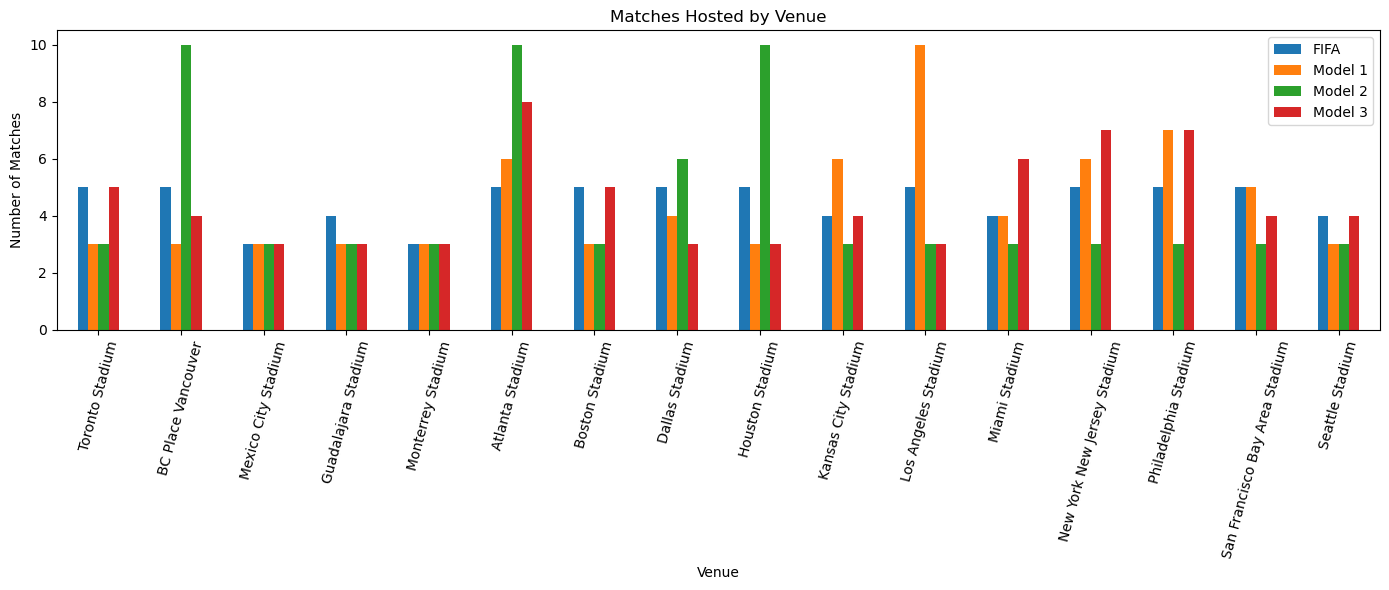

In [356]:
# venue allocation chart

venue_plot = (
    venue_comparison[
        [
            "venue_name",
            "FIFA",
            "Model 1",
            "Model 2",
            "Model 3"
        ]
    ]
    .set_index(
        "venue_name"
    )
)


venue_plot.plot(
    kind="bar",
    figsize=(14, 6)
)


plt.title(
    "Matches Hosted by Venue"
)

plt.xlabel(
    "Venue"
)

plt.ylabel(
    "Number of Matches"
)

plt.xticks(
    rotation=75
)

plt.tight_layout()

plt.show()

In [357]:
# fifa vs recommended model

recommendation_rows = []


for metric in core_metrics:

    fifa_value = (
        fifa_baseline[metric]
    )

    recommended_value = (
        model2_summary[metric]
    )


    percent_change = (
        (
            recommended_value
            - fifa_value
        )
        / fifa_value
    ) * 100


    comparison = compare_with_fifa(
        recommended_value,
        fifa_value,
        desired_direction[metric]
    )


    recommendation_rows.append({

        "Metric":
            metric_labels[metric],

        "FIFA":
            fifa_value,

        "Recommended Model 2":
            recommended_value,

        "Change vs FIFA (%)":
            percent_change,

        "Assessment":
            comparison
    })


recommended_comparison = pd.DataFrame(
    recommendation_rows
)


display(
    recommended_comparison.round(2)
)

,Metric,FIFA,Recommended Model 2,Change vs FIFA (%),Assessment
0,Total Travel Time (hours),641.49,749.64,16.86,Worse
1,Travel-Time SD (hours),4.22,4.23,0.27,Comparable
2,Minimum Effective Recovery (hours),86.00,96.57,12.30,Better
3,Effective-Recovery SD (hours),19.46,17.38,-10.68,Better
4,Average Time-Zone Displacement (hours),0.33,0.23,-29.79,Better
5,Total Weather Exposure,3926.58,2453.70,-37.51,Better
6,Total Broadcast Penalty,644920.69,443325.19,-31.26,Better
7,Seating Opportunity,4793722.00,4816767.00,0.48,Comparable
8,Venue-Use Imbalance (SD),0.71,2.74,287.30,Worse


## Final Recommendation

### Model 2 is recommended as the preferred alternative to FIFA's current group-stage schedule. Although Model 2 increases total travel and produces a less even distribution of matches across venues, it provides substantial improvements in several other dimensions. Compared with FIFA, it increases minimum effective recovery, reduces variation in effective recovery, reduces average time-zone displacement, substantially reduces modeled weather exposure, and improves broadcast accessibility while maintaining seating opportunity.

### Models 1 and 3 demonstrate the trade-offs associated with prioritizing individual objectives. Model 1 achieves the lowest total travel but worsens several player-welfare measures, while Model 3 achieves the lowest broadcast penalty but produces substantial increases in travel and reductions in player recovery. Model 2 therefore provides the strongest overall compromise among the three optimized alternatives.